In [32]:
import numpy as np
import matplotlib.pyplot as plt

from resflow.utils.plotting_lobes import custom_cmap, draw_mask_boundary

## Load Data
Volume convention: axis 0 = X (horizontal), axis 1 = Y (horizontal), axis 2 = Z (depth).

In [33]:
results_dir = 'results'

res_nw = np.load(f'{results_dir}/big_reservoir_no_wells.npy')      # (X, Y, Z) int8
res_ww = np.load(f'{results_dir}/big_reservoir_with_wells.npy')    # (X, Y, Z) int8
well_mask = np.load(f'{results_dir}/well_mask_assembled.npy')      # (X, Y, Z) float32
cond_map = np.load(f'{results_dir}/conditioning_map.npy')          # (ny, nx, 5) float32
timing = np.load(f'{results_dir}/timing.npz', allow_pickle=True)

NX, NY, NZ = res_nw.shape
STRIDE = 48

print(f"No-wells:   {res_nw.shape} (X, Y, Z_depth), NTG={res_nw.mean():.3f}")
print(f"With-wells: {res_ww.shape}, NTG={res_ww.mean():.3f}")
print(f"Well mask:  {well_mask.shape}, voxels={well_mask.sum():.0f}")
print(f"Timing:     no-wells {float(timing['total_no_wells']):.1f}s, "
      f"with-wells {float(timing['total_with_wells']):.1f}s")

No-wells:   (320, 320, 50) (X, Y, Z_depth), NTG=0.631
With-wells: (320, 320, 50), NTG=0.631
Well mask:  (320, 320, 50), voxels=9027
Timing:     no-wells 43.6s, with-wells 43.3s


In [34]:
def draw_block_grid(ax, dim_size, stride, direction='vertical',
                    color='white', linewidth=0.5, alpha=0.4):
    """Draw dashed grid lines at block boundaries."""
    for pos in range(50, dim_size, stride):
        if direction == 'vertical':
            ax.axvline(pos - 0.5, color=color, lw=linewidth, ls='--', alpha=alpha)
        else:
            ax.axhline(pos - 0.5, color=color, lw=linewidth, ls='--', alpha=alpha)


def find_well_slices(well_mask_vol, slice_axis, n_slices=8):
    """Find slice positions that contain the most well voxels.

    Falls back to evenly spaced positions if no wells on that axis.
    """
    dim_size = well_mask_vol.shape[slice_axis]
    counts = np.array([np.take(well_mask_vol, i, axis=slice_axis).sum()
                       for i in range(dim_size)])
    if counts.sum() == 0:
        return np.linspace(10, dim_size - 10, n_slices, dtype=int).tolist()
    # Pick top n_slices positions with most well voxels, sorted by index
    top_indices = np.argsort(counts)[-n_slices:]
    return sorted(top_indices.tolist())


def plot_big_slice(vol, title, slice_axis, slice_idx, xlabel, ylabel,
                   well_mask_vol=None, grid_h=None, grid_v=None, figsize=None):
    """Plot a single large slice from the big reservoir."""
    slc = np.take(vol, slice_idx, axis=slice_axis).T.astype(float)
    if figsize is None:
        h, w = slc.shape
        figsize = (max(14, w / 30), max(4, h / 30))

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(slc, cmap=custom_cmap, vmin=0, vmax=1, origin='lower',
              aspect='equal' if slc.shape[0] > 100 else 'auto')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if grid_h is not None:
        draw_block_grid(ax, grid_h, STRIDE, 'vertical')
    if grid_v is not None:
        draw_block_grid(ax, grid_v, STRIDE, 'horizontal')

    if well_mask_vol is not None:
        mask_slc = np.take(well_mask_vol, slice_idx, axis=slice_axis).T
        if mask_slc.any():
            red = np.zeros((*mask_slc.shape, 4))
            red[mask_slc > 0.5] = [1, 0, 0, 0.12]
            ax.imshow(red, origin='lower',
                      aspect='equal' if slc.shape[0] > 100 else 'auto')
            draw_mask_boundary(ax, mask_slc, color='red', linewidth=0.5)

    plt.tight_layout()
    plt.show()

## Depth Slices (Top-Down Views) — XY Plane
Horizontal cross-sections at 4 depths. One plot per depth, stacked vertically.

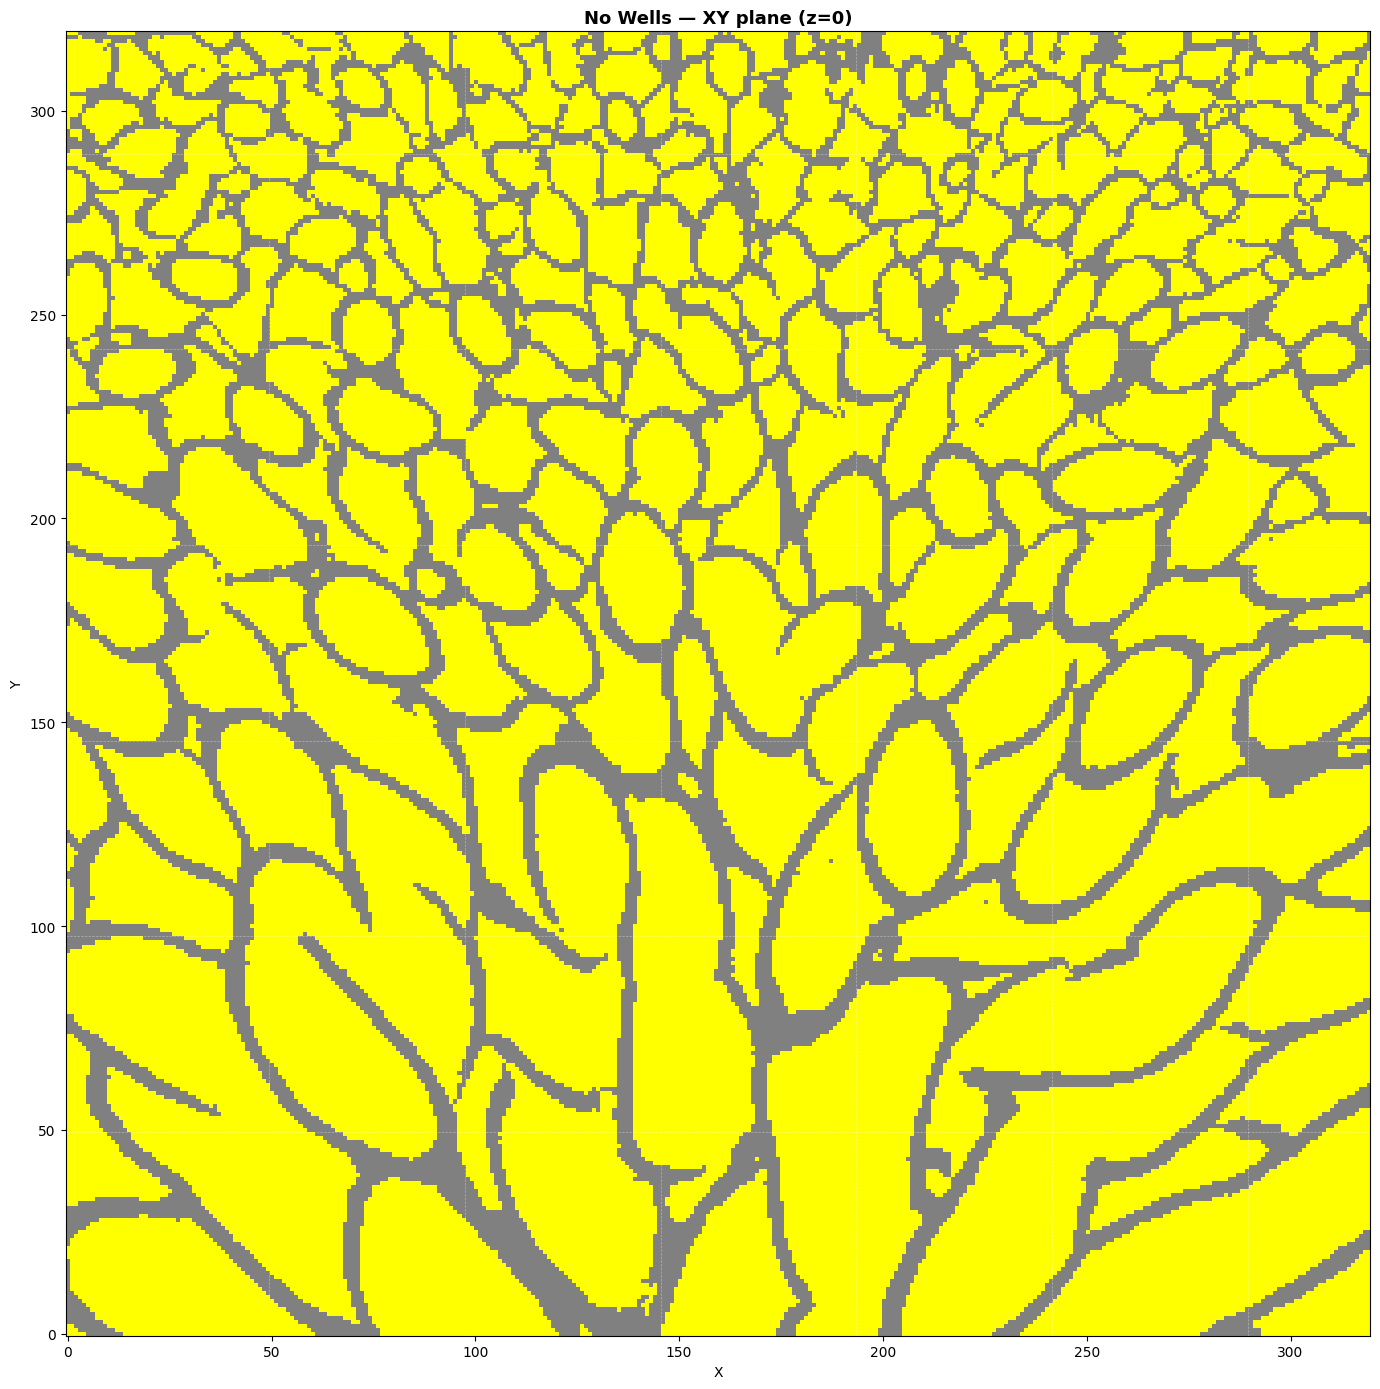

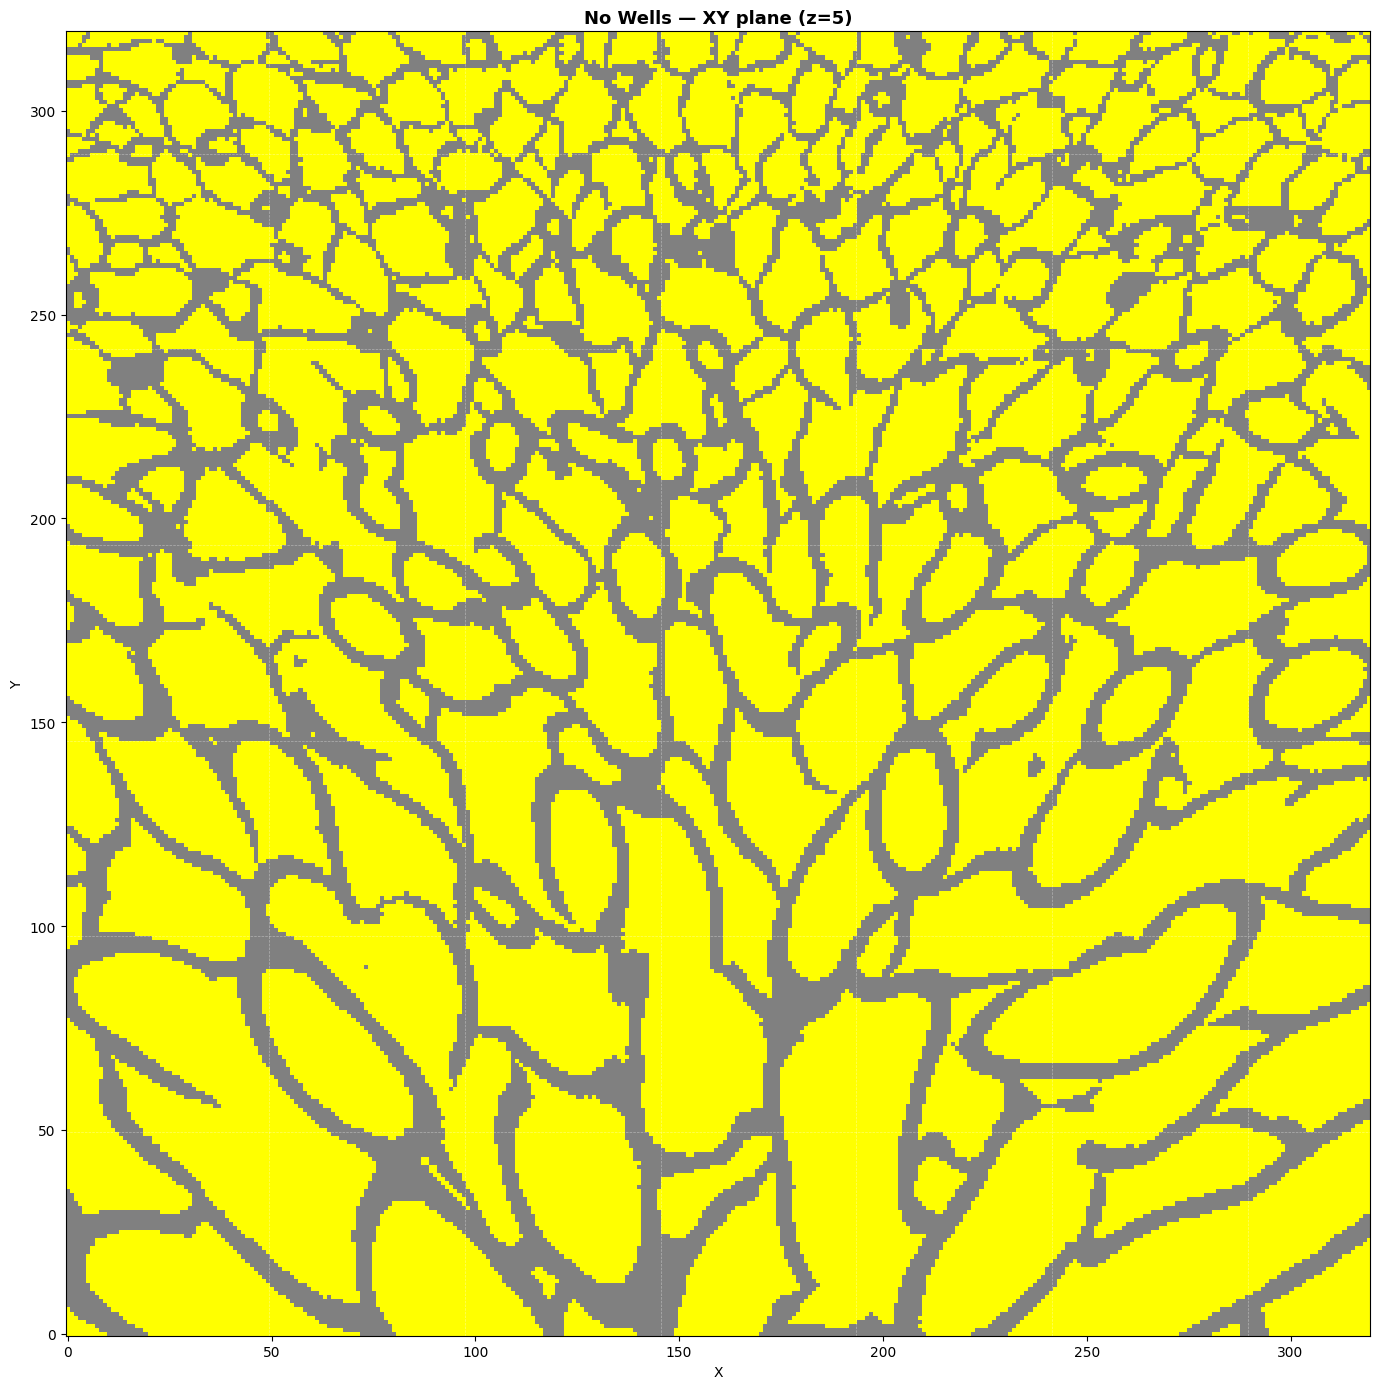

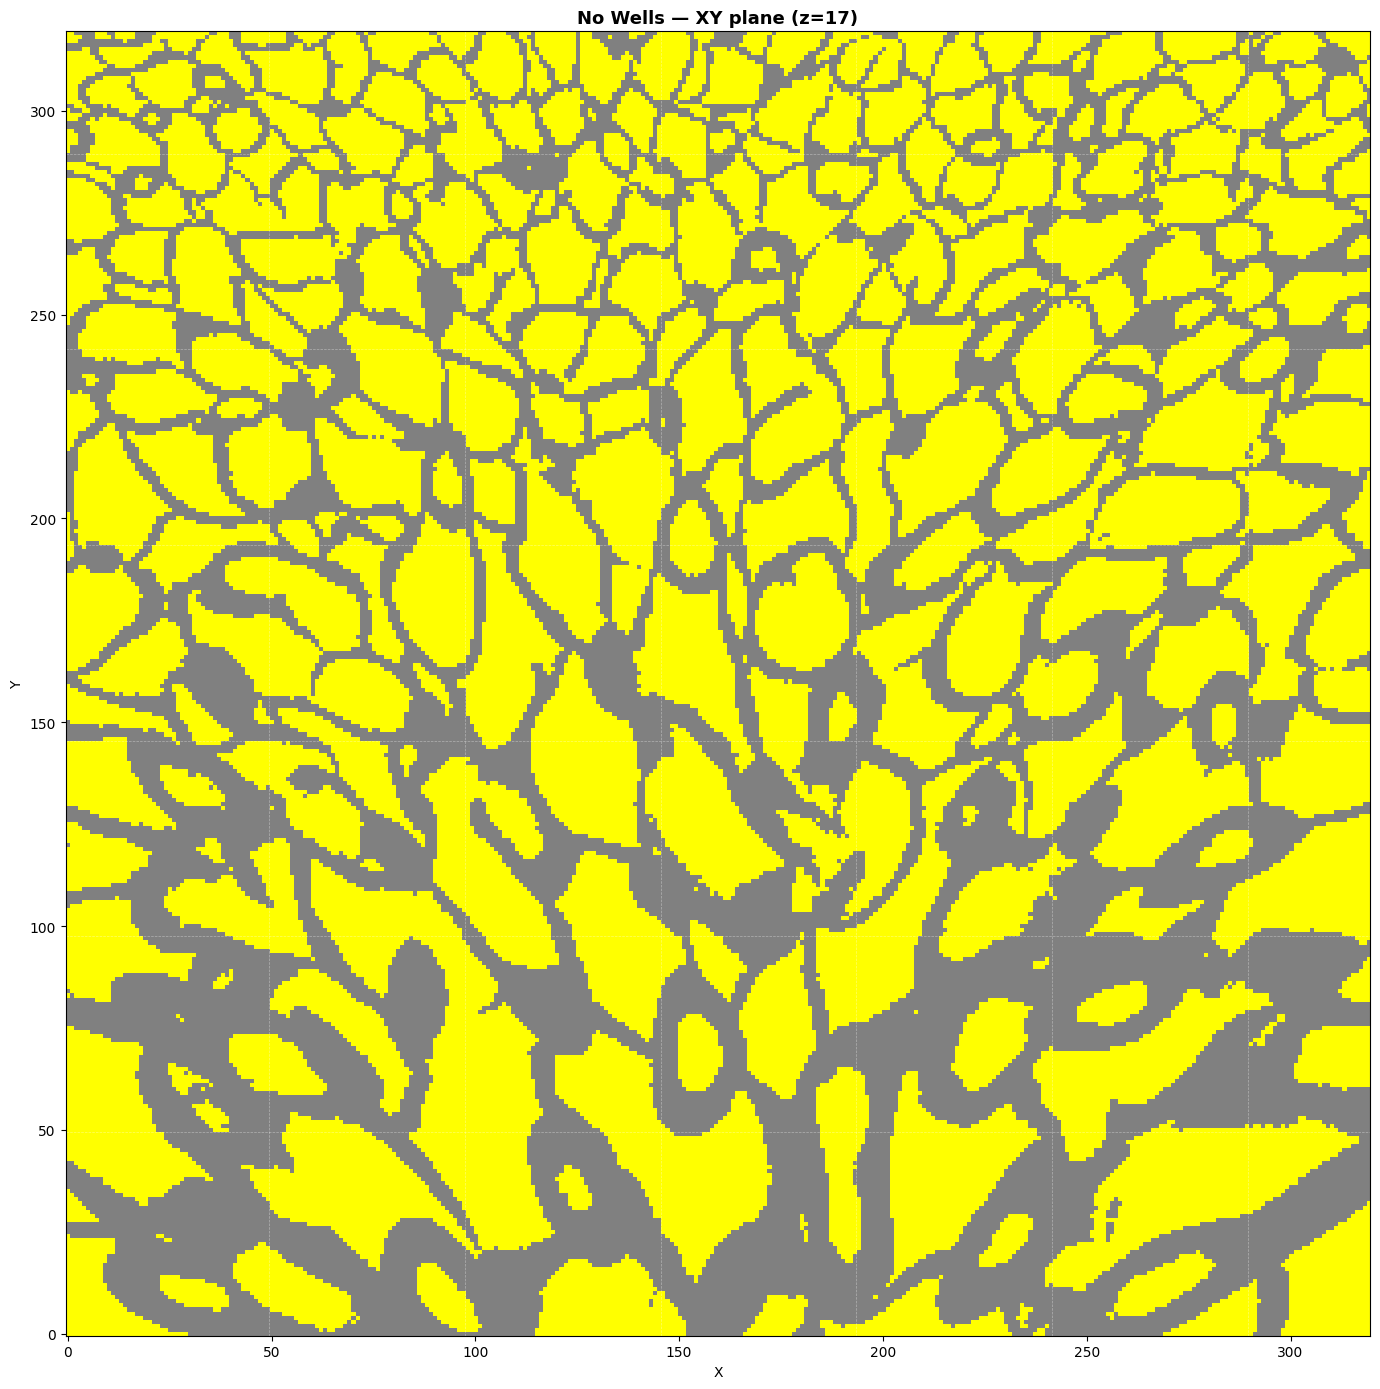

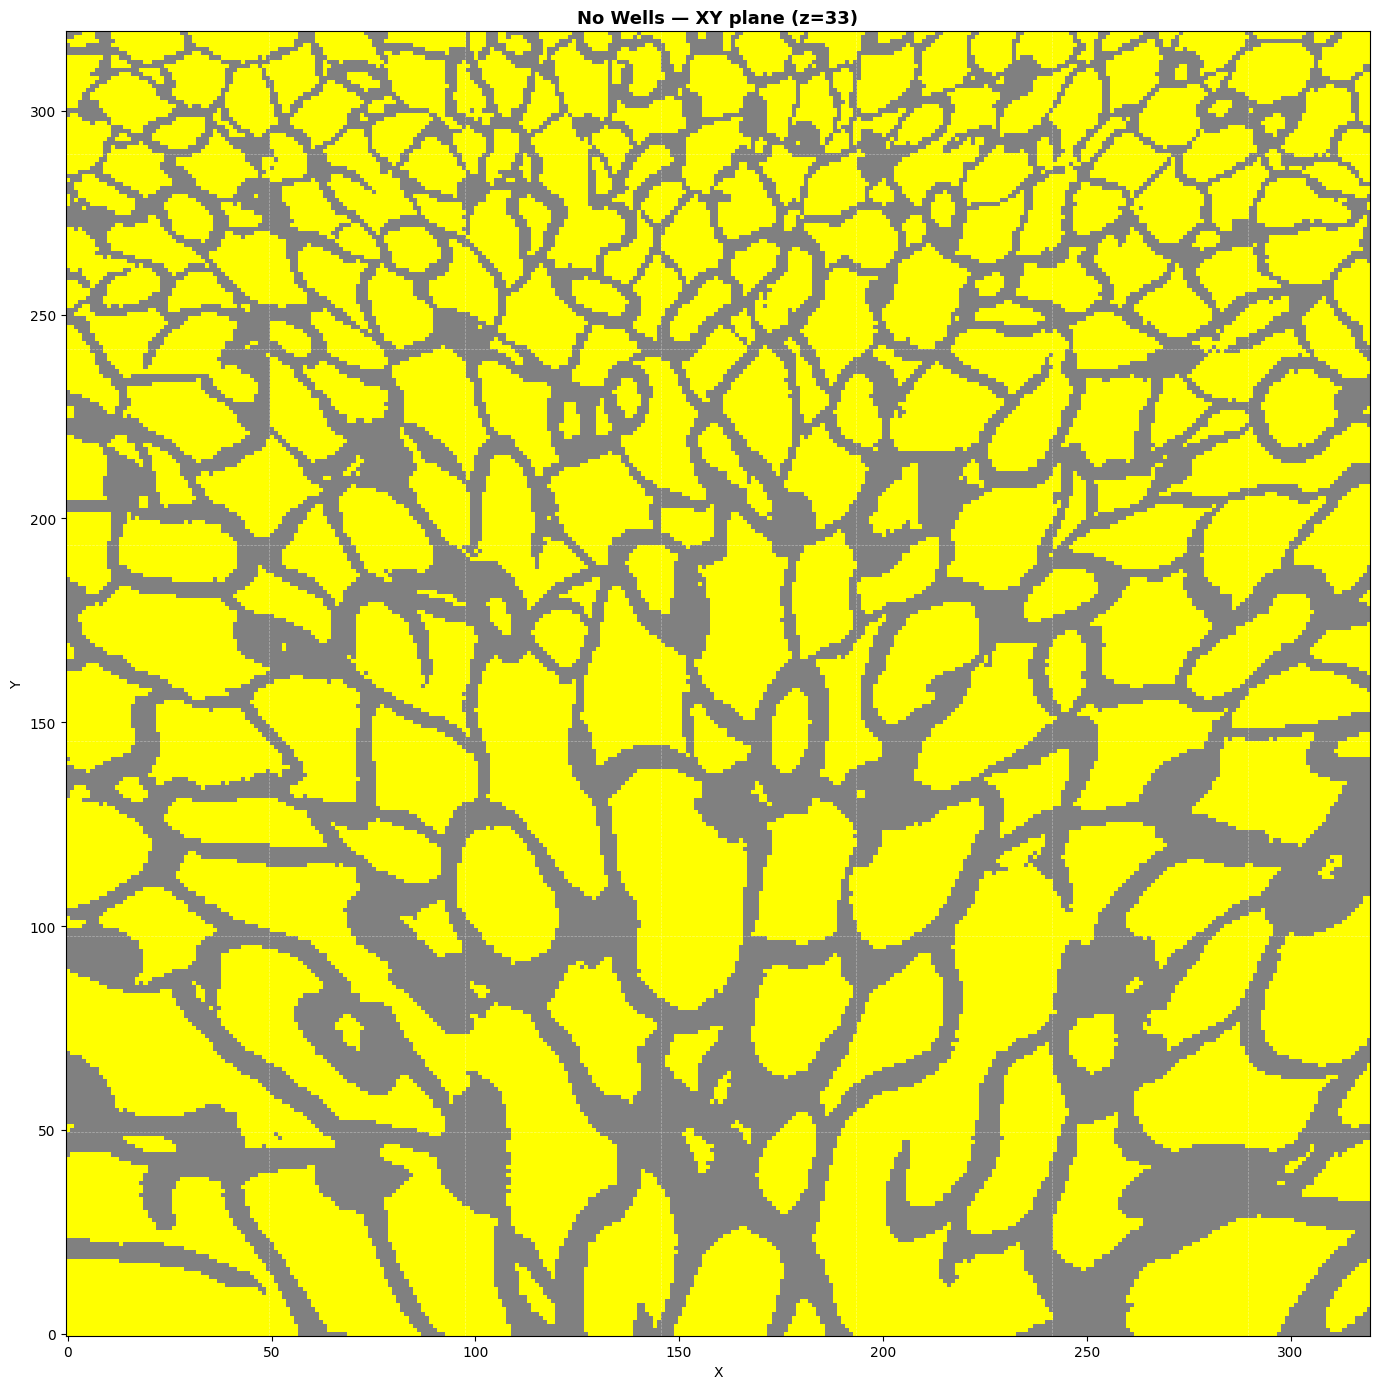

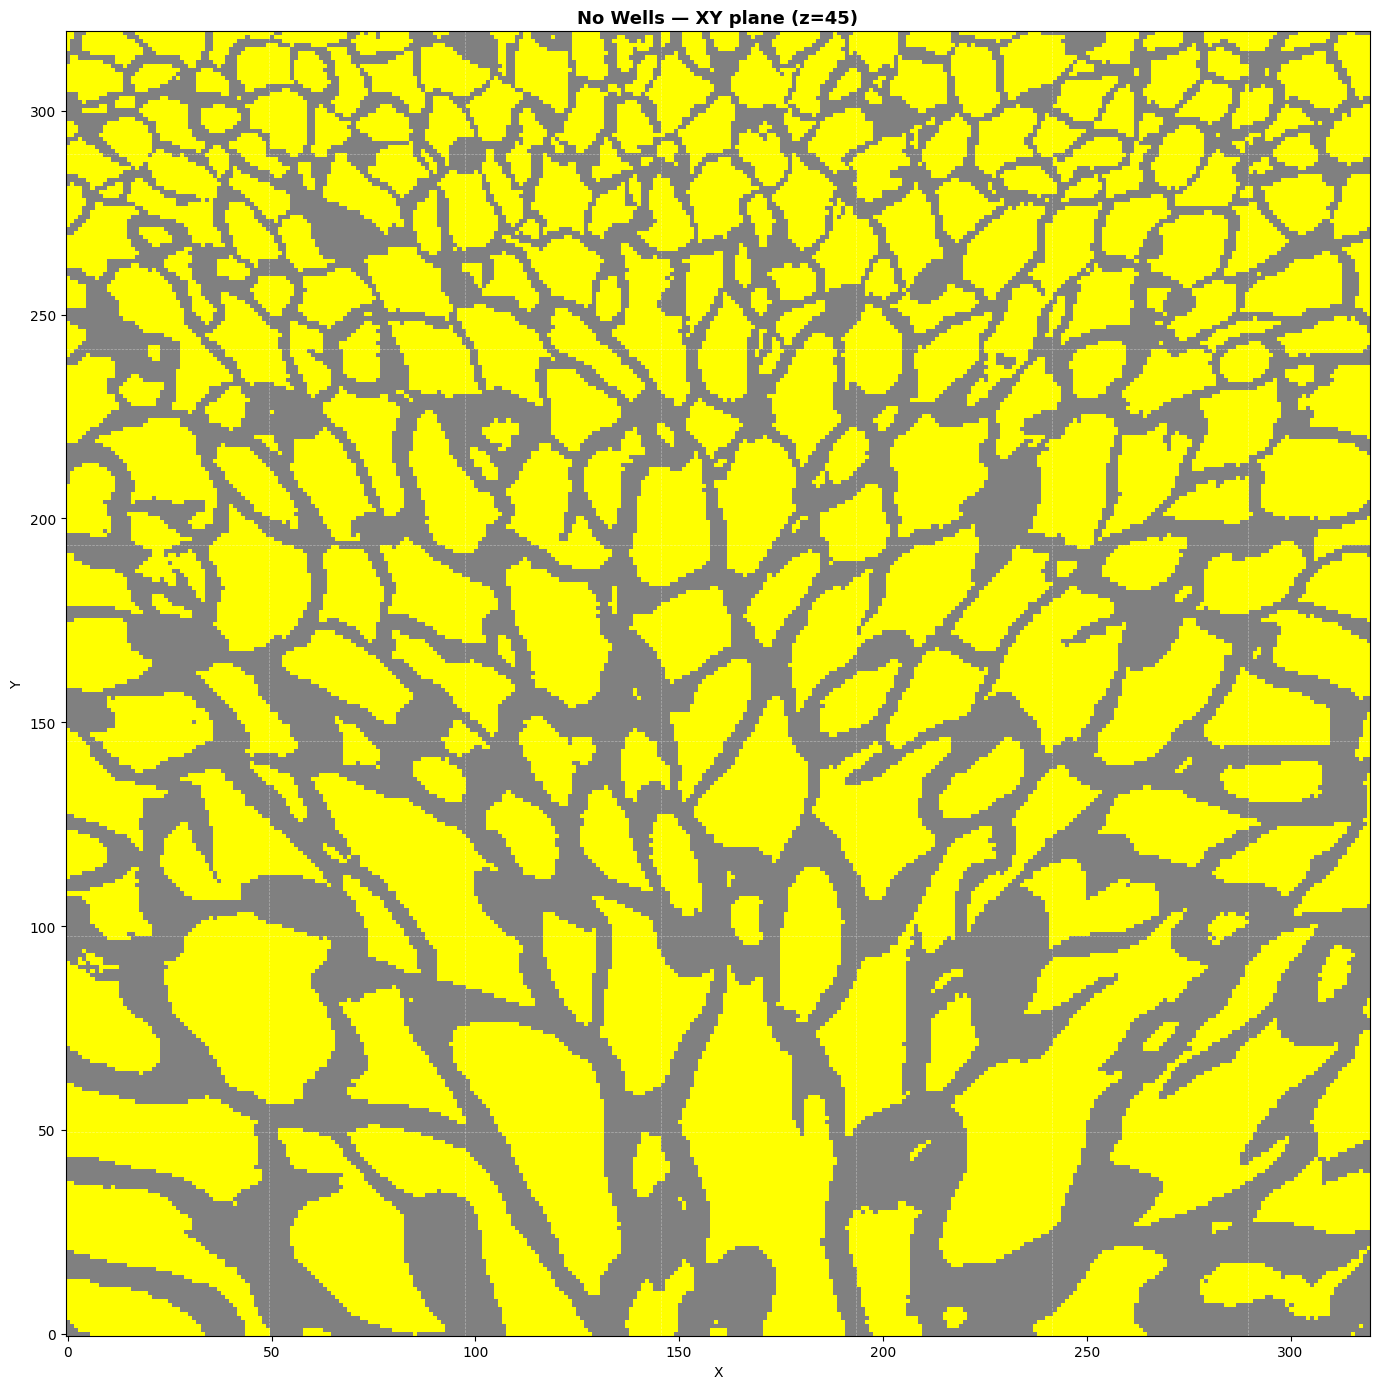

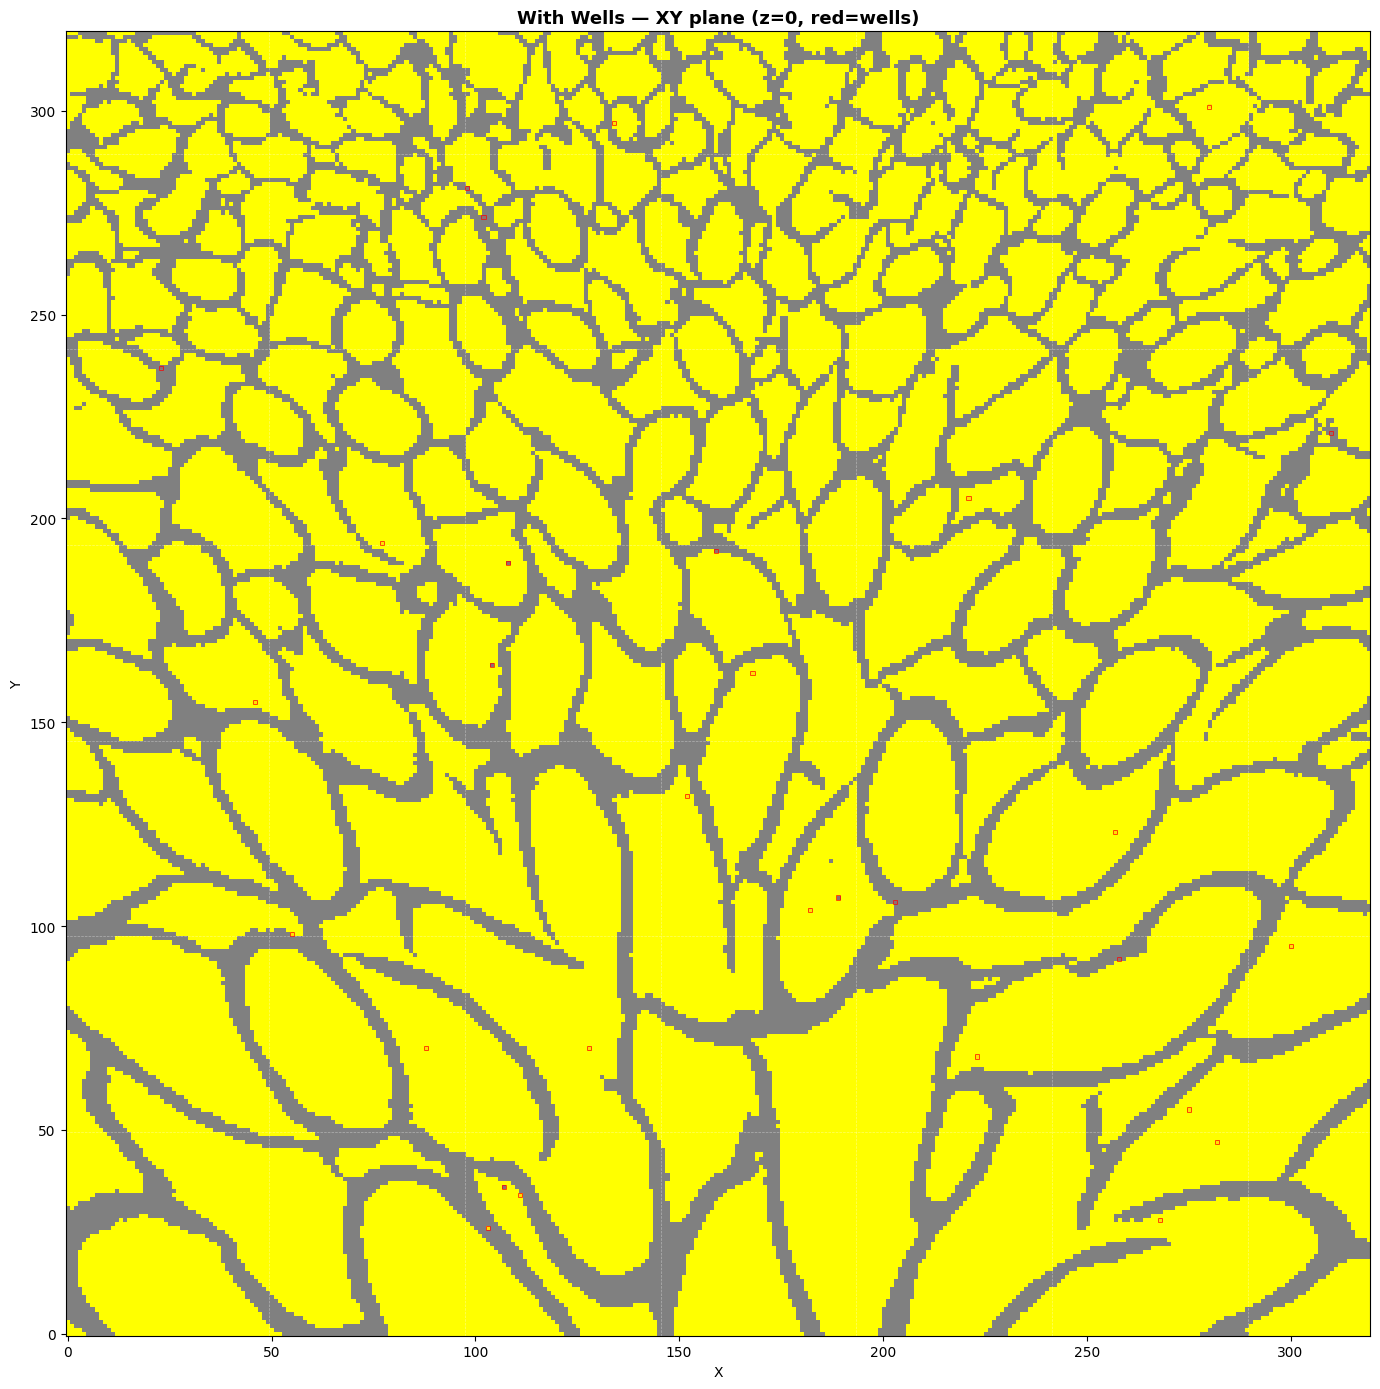

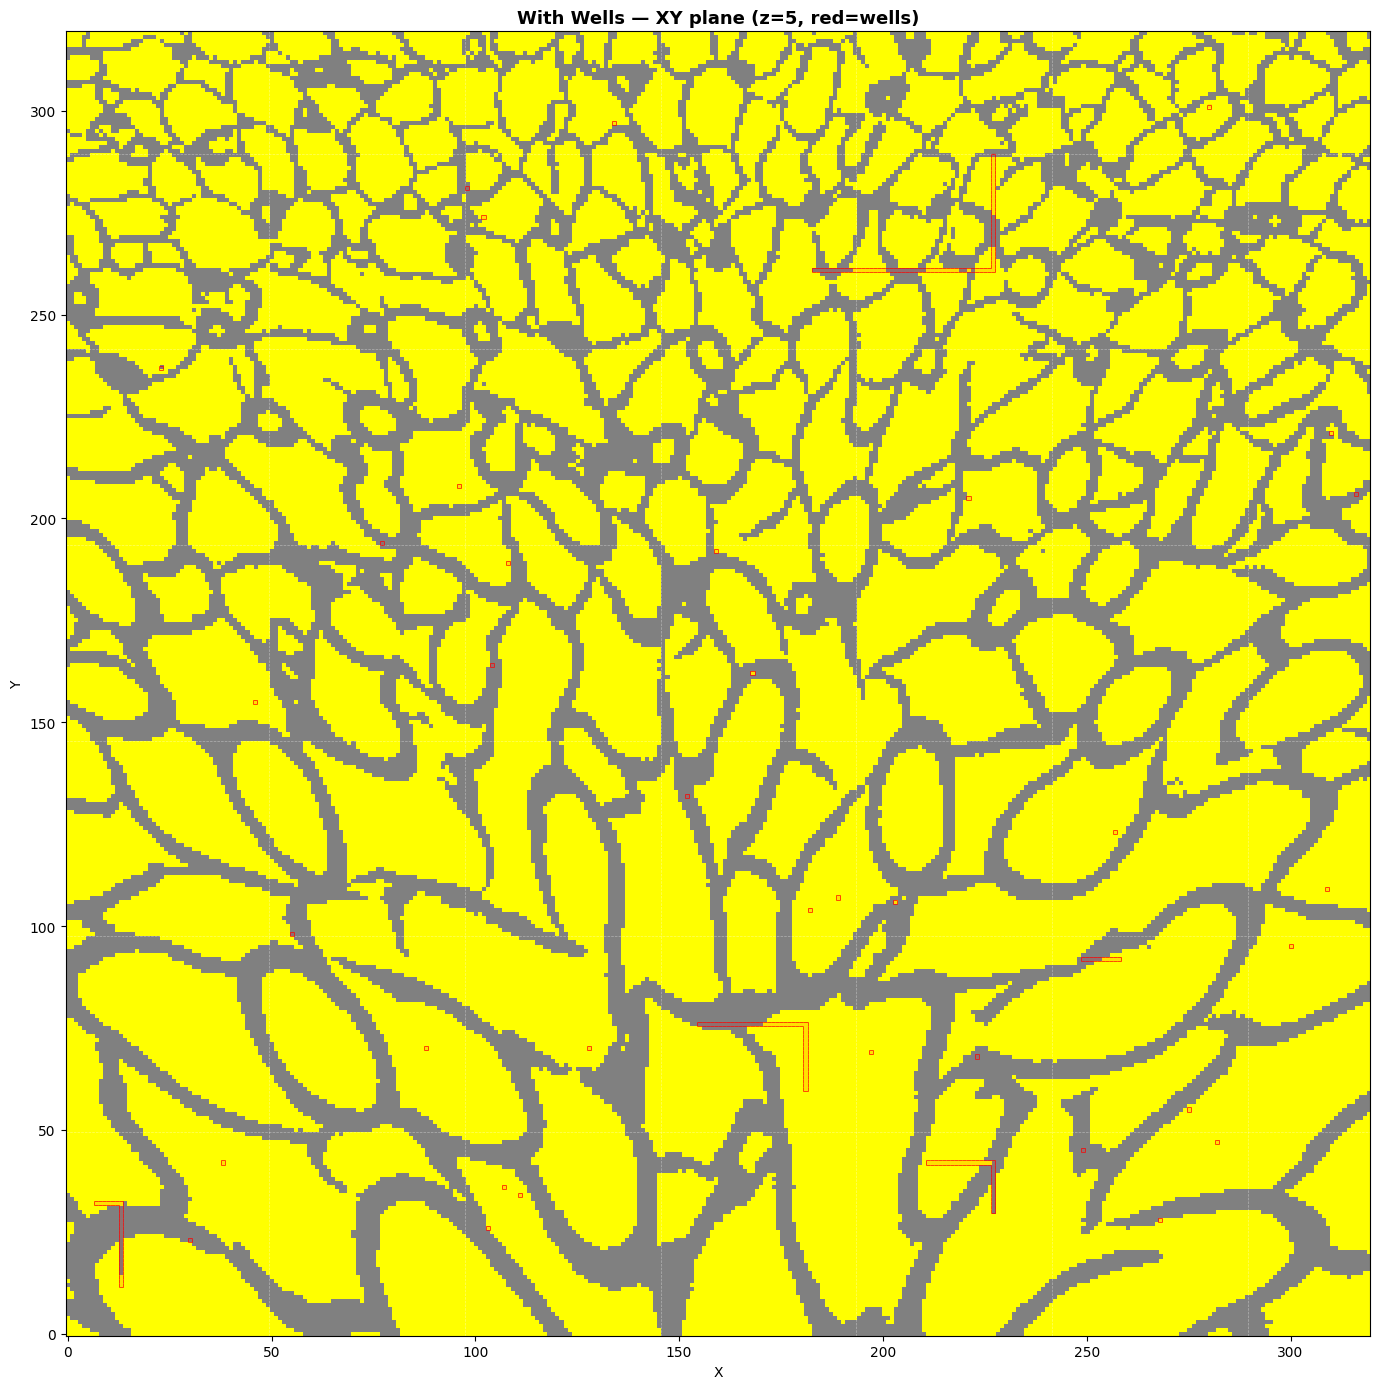

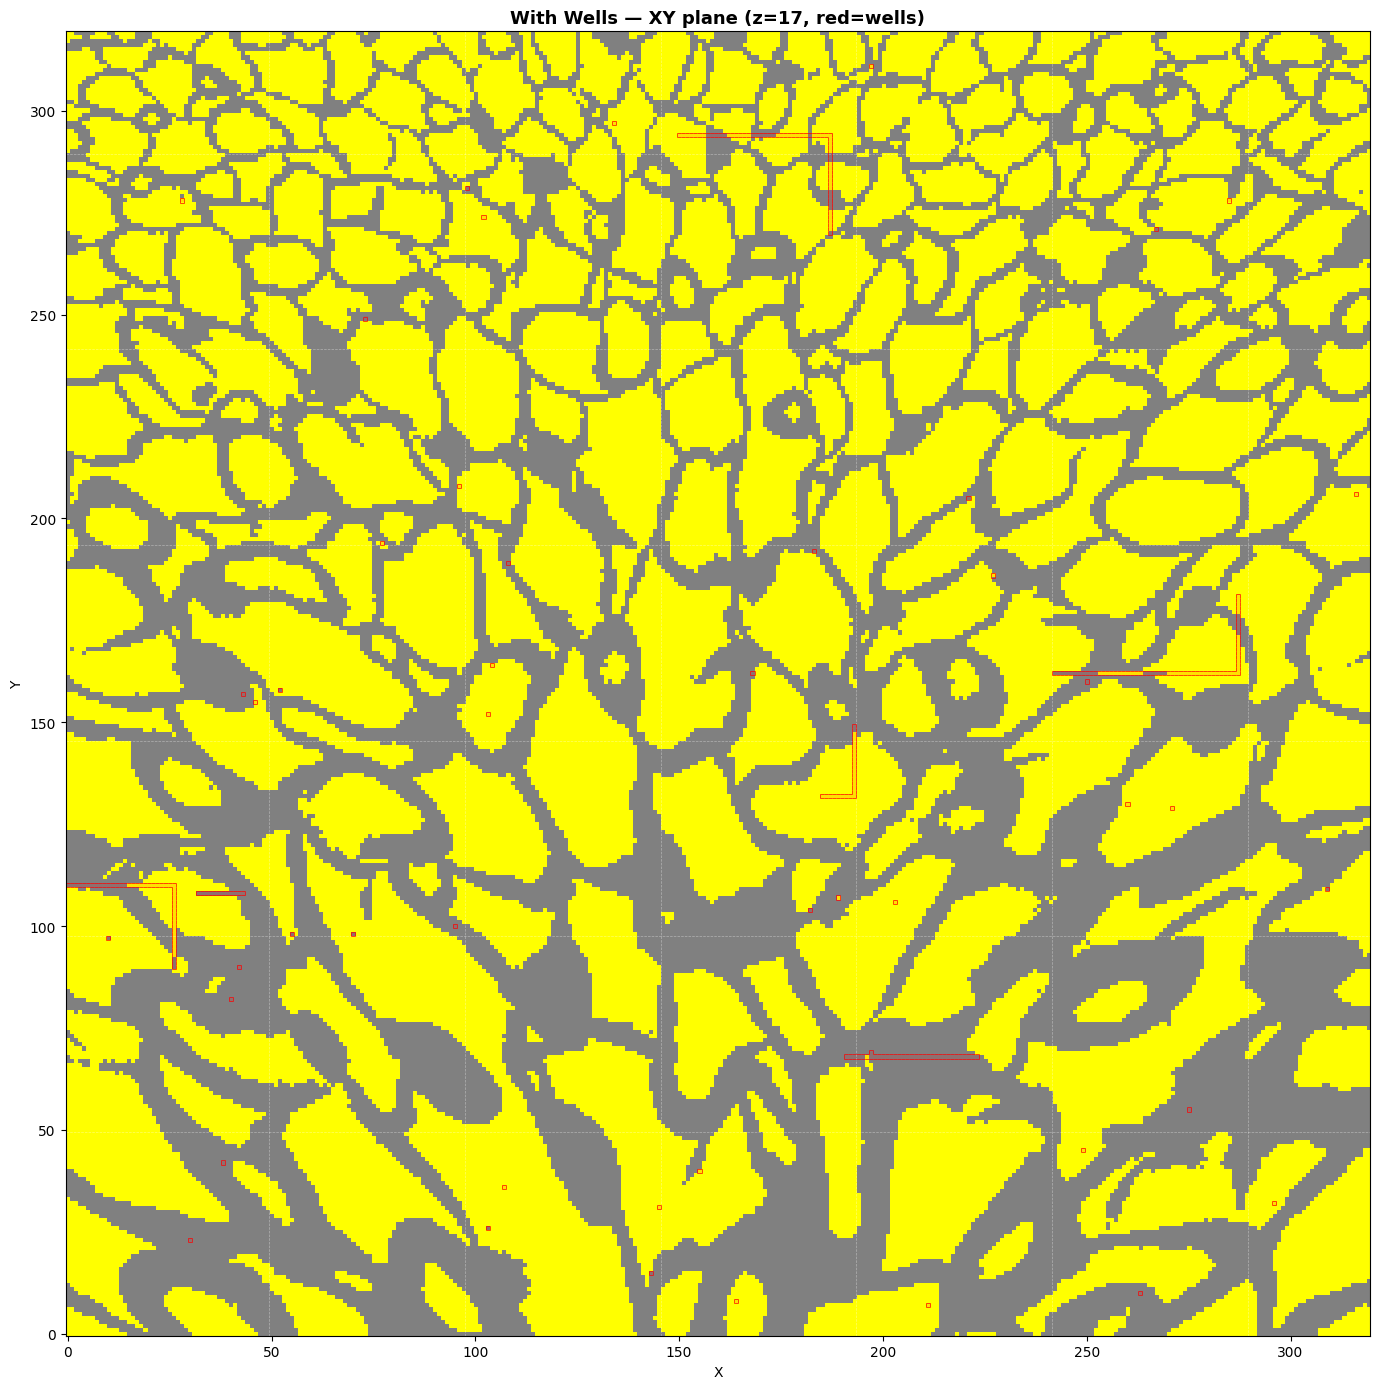

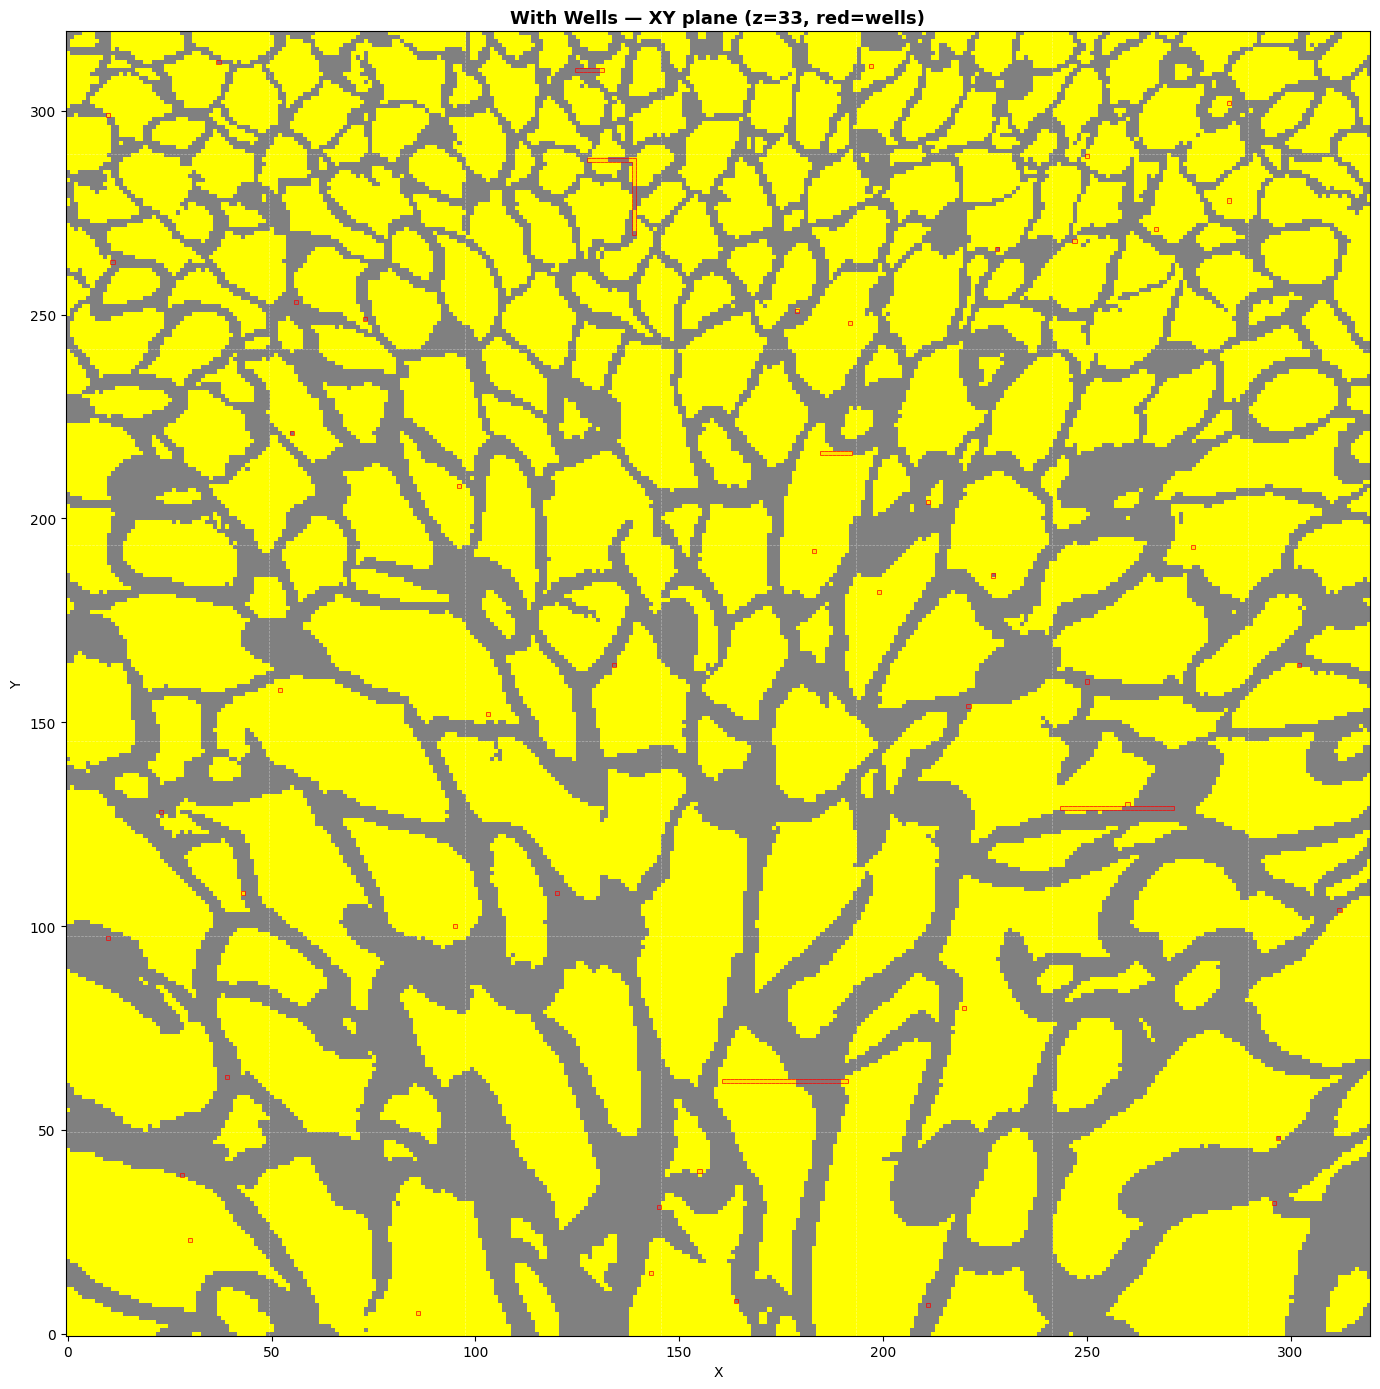

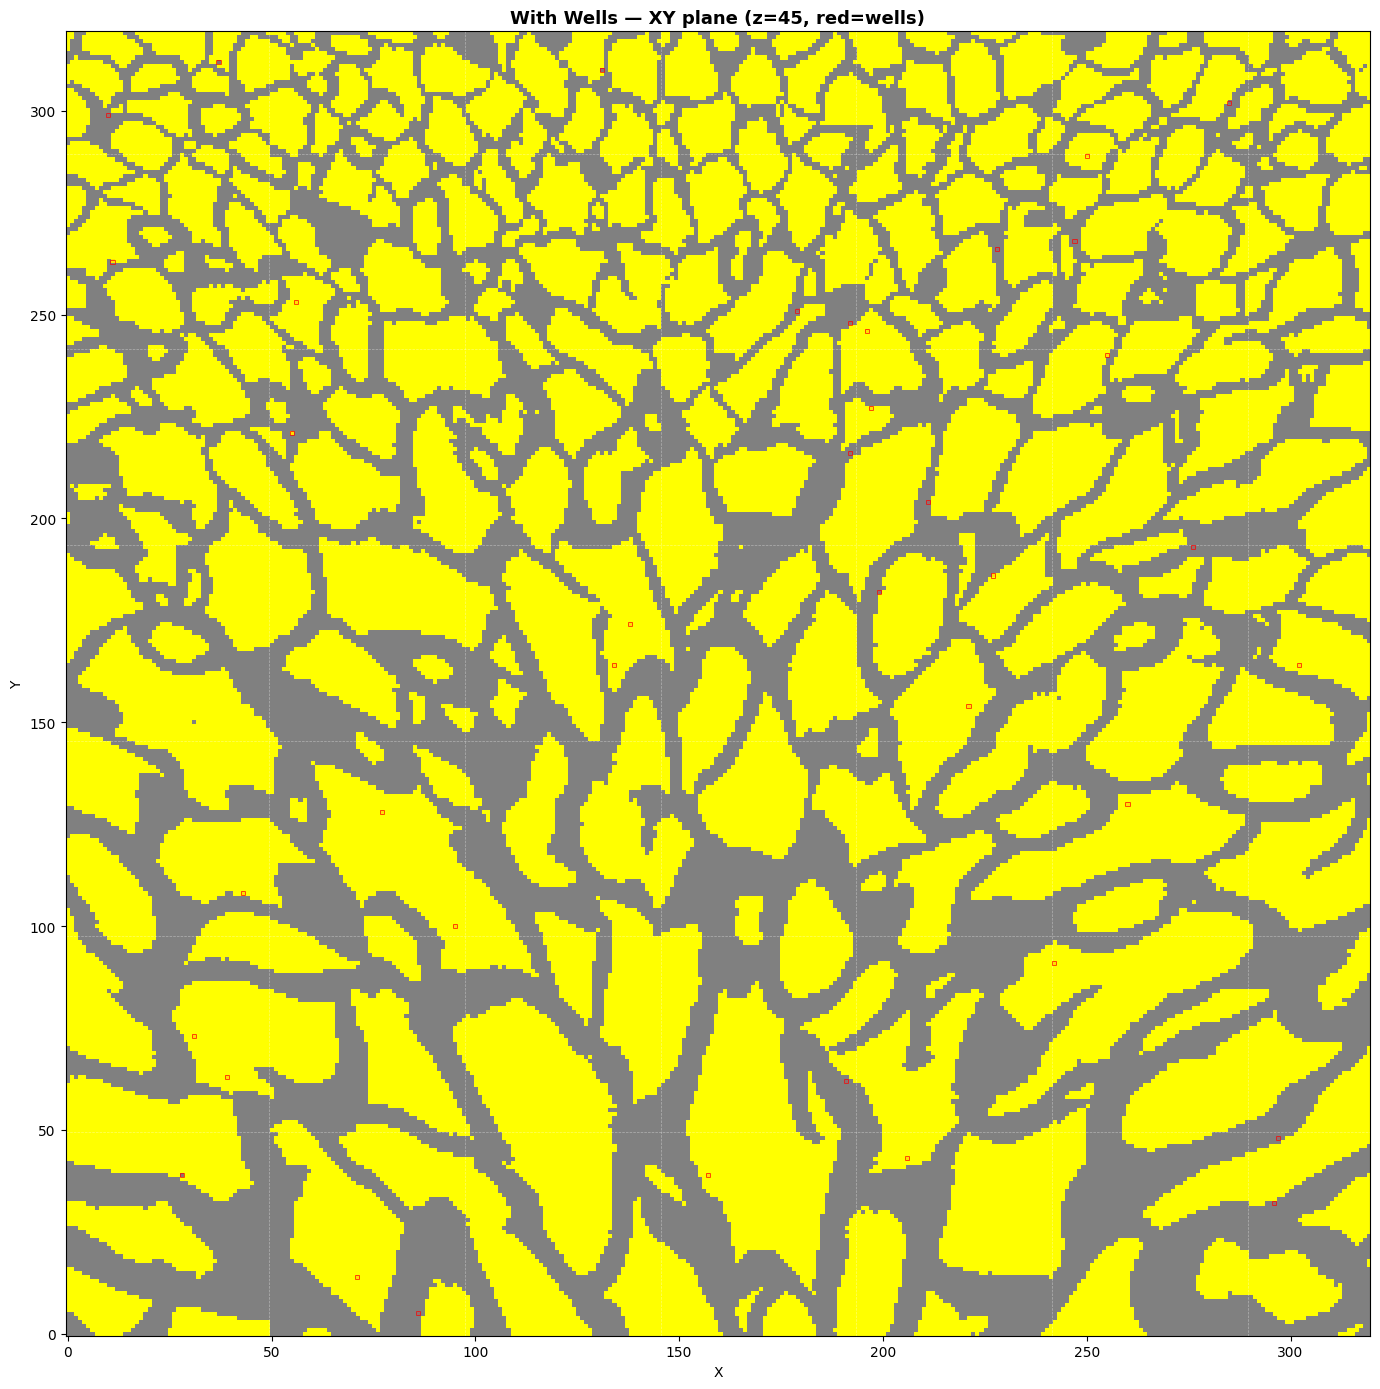

In [35]:
z_slices = [0, 5, 17, 33, 45]

for z in z_slices:
    plot_big_slice(res_nw, f'No Wells — XY plane (z={z})',
                   slice_axis=2, slice_idx=z, xlabel='X', ylabel='Y',
                   grid_h=NX, grid_v=NY, figsize=(14, 14))

for z in z_slices:
    plot_big_slice(res_ww, f'With Wells — XY plane (z={z}, red=wells)',
                   slice_axis=2, slice_idx=z, xlabel='X', ylabel='Y',
                   well_mask_vol=well_mask, grid_h=NX, grid_v=NY, figsize=(14, 14))

## Y Cross-Sections — XZ Plane
Vertical cross-sections at 8 Y positions. Depth (Z) on vertical axis, X on horizontal.

Y slices through wells: [42, 100, 164, 192, 221, 278, 281, 289]


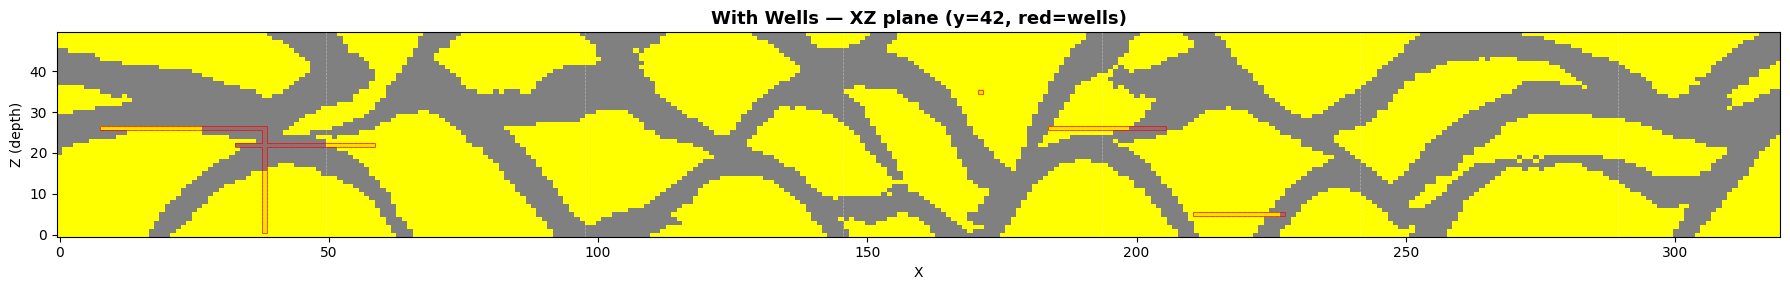

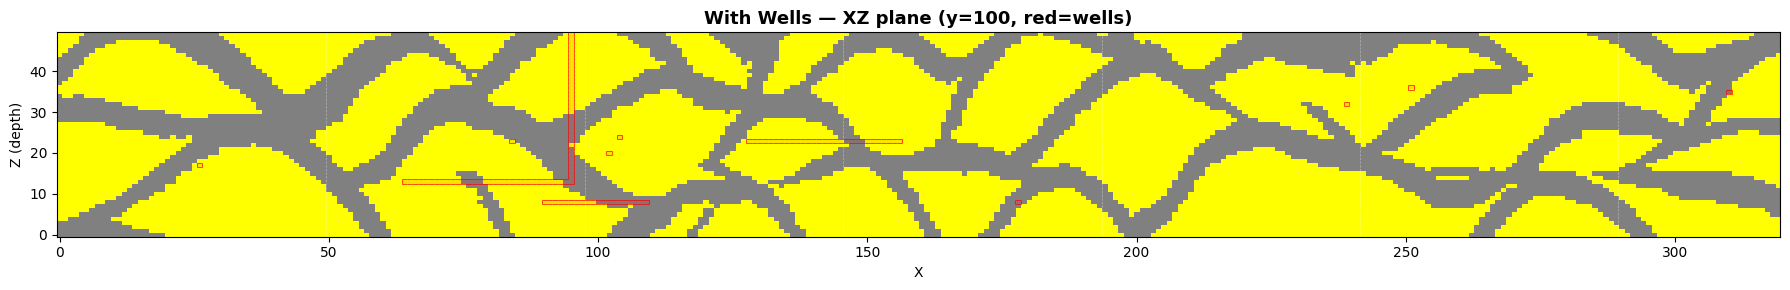

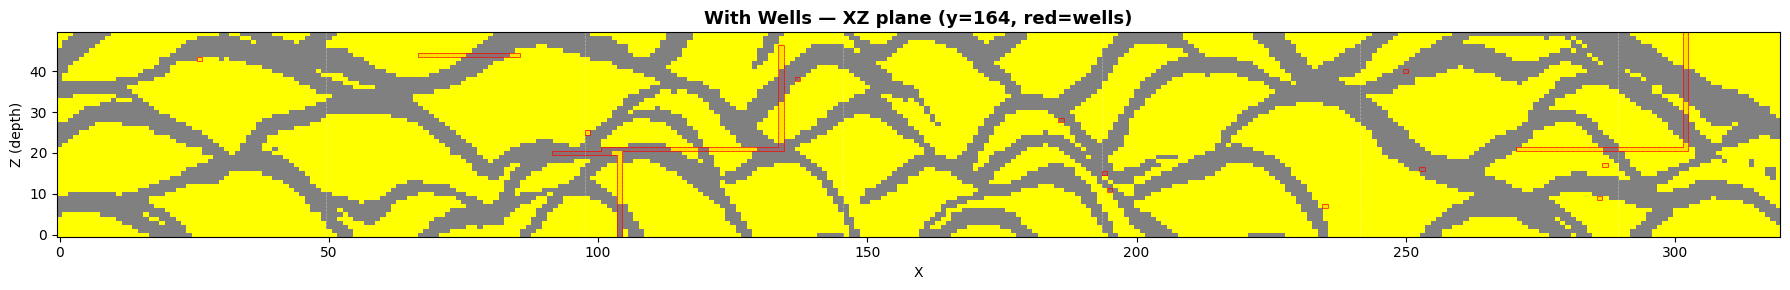

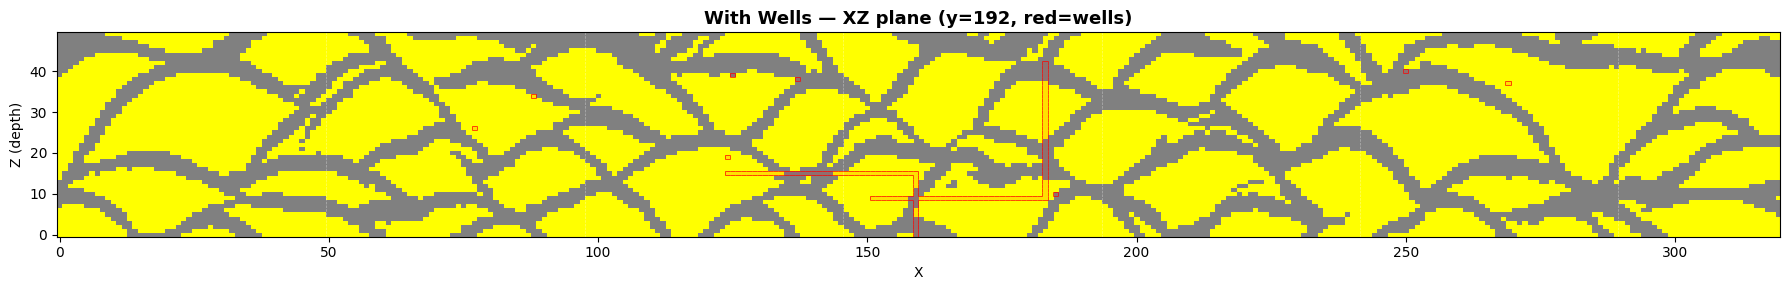

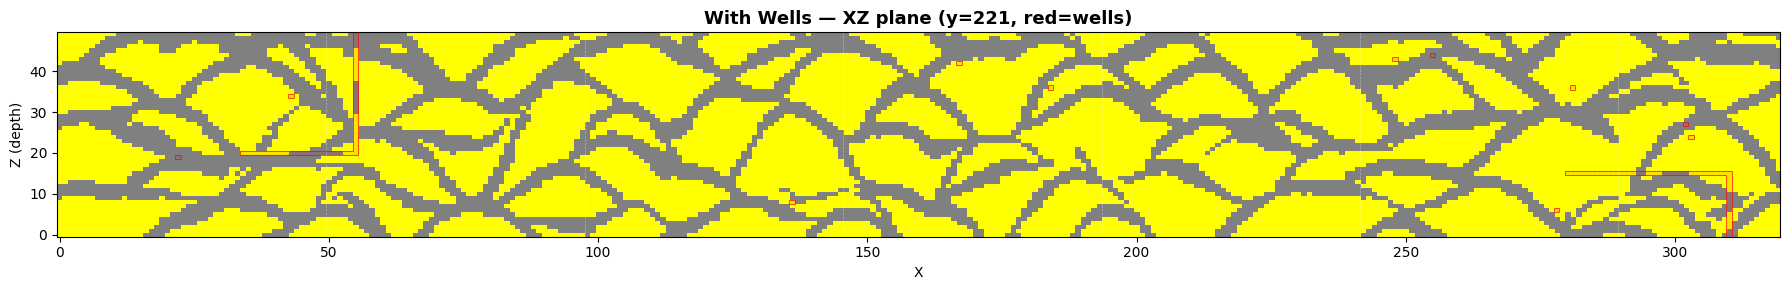

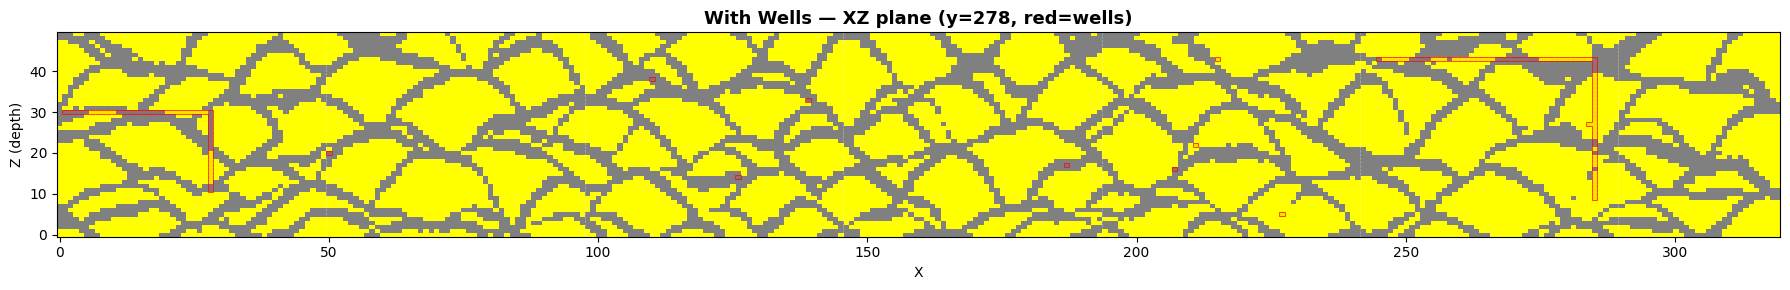

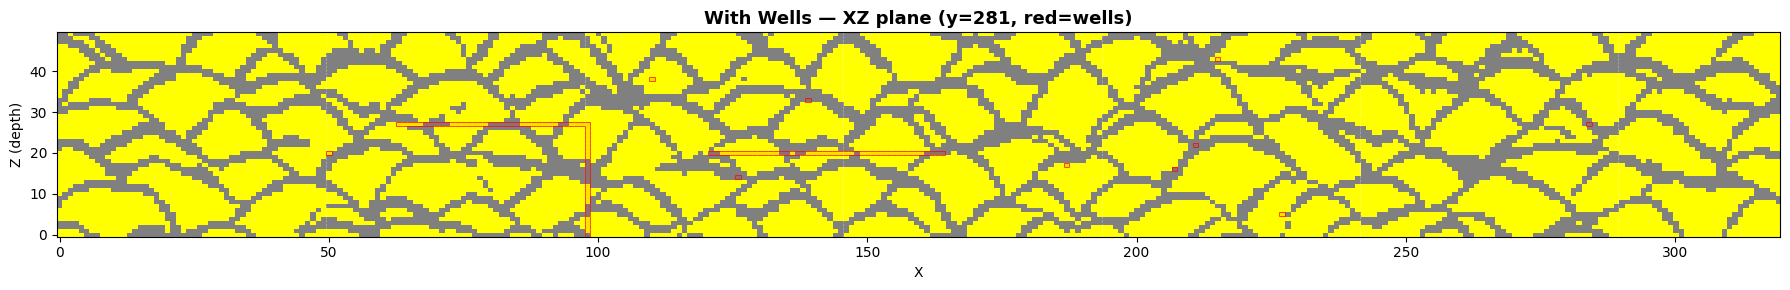

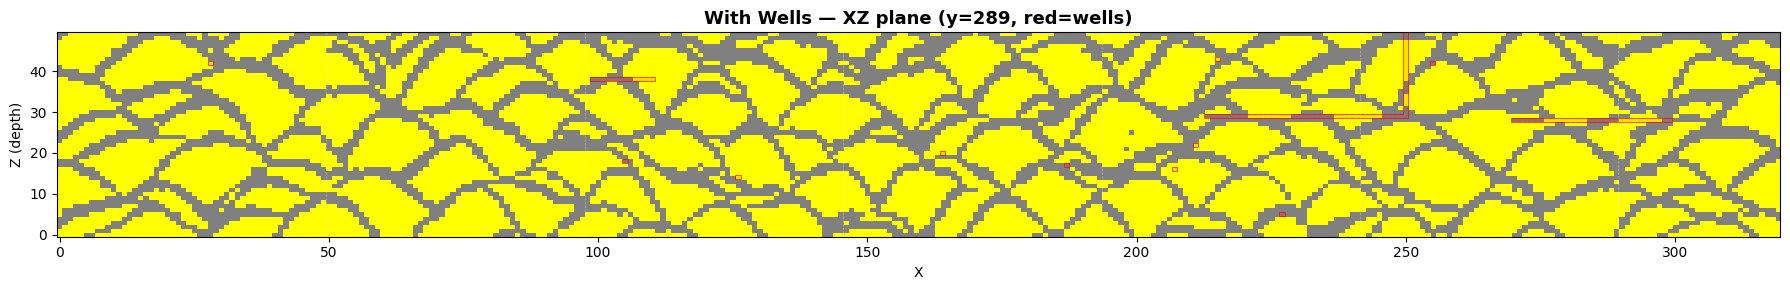

In [36]:
y_slices = np.linspace(10, NY - 10, 8, dtype=int).tolist()

# for y in y_slices:
#     plot_big_slice(res_nw, f'No Wells — XZ plane (y={y})',
#                    slice_axis=1, slice_idx=y, xlabel='X', ylabel='Z (depth)',
#                    grid_h=NX, figsize=(18, 3))

# For with-wells: pick Y positions that pass through wells
y_well_slices = find_well_slices(well_mask, slice_axis=1, n_slices=8)
print(f"Y slices through wells: {y_well_slices}")

for y in y_well_slices:
    plot_big_slice(res_ww, f'With Wells — XZ plane (y={y}, red=wells)',
                   slice_axis=1, slice_idx=y, xlabel='X', ylabel='Z (depth)',
                   well_mask_vol=well_mask, grid_h=NX, figsize=(18, 3))

## X Cross-Sections — YZ Plane
Vertical cross-sections at 8 X positions. Depth (Z) on vertical axis, Y on horizontal.

X slices through wells: [43, 103, 134, 197, 211, 227, 250, 255]


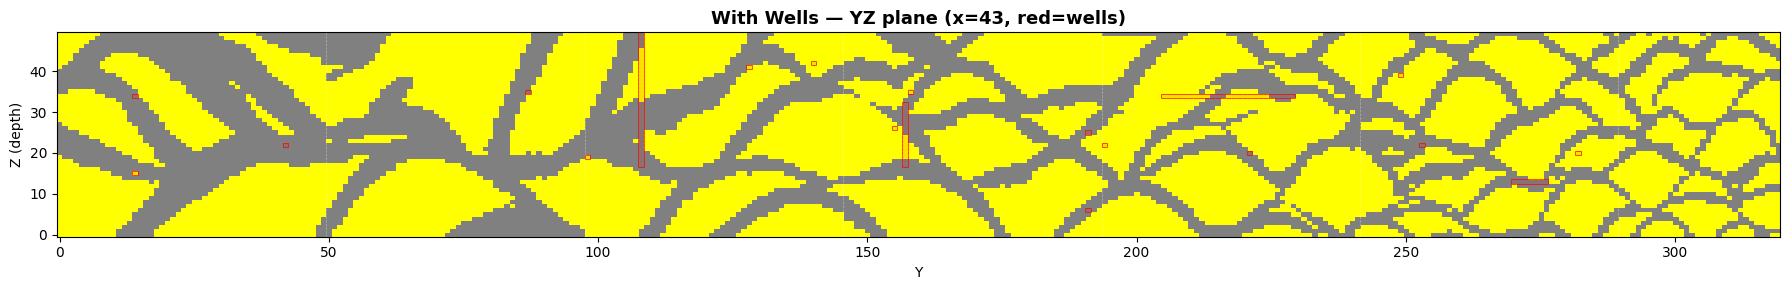

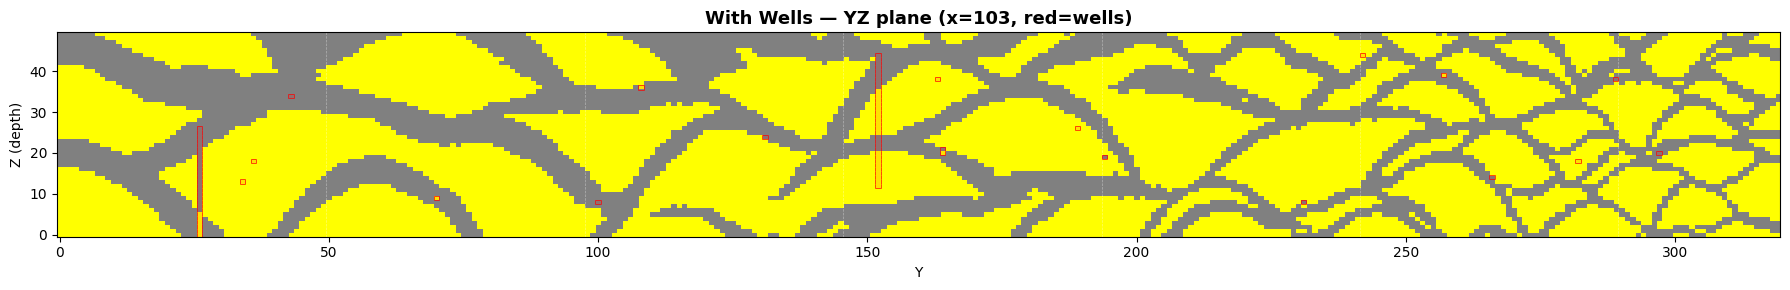

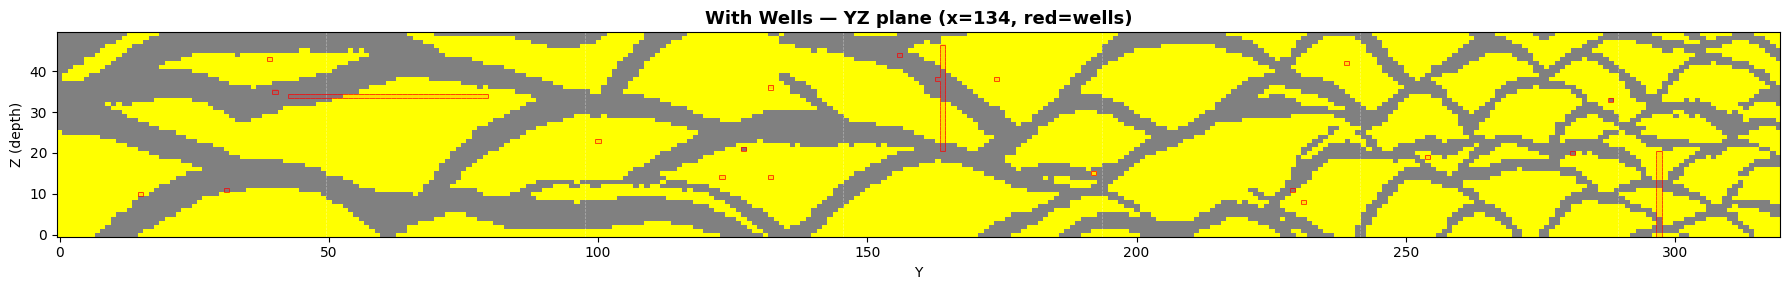

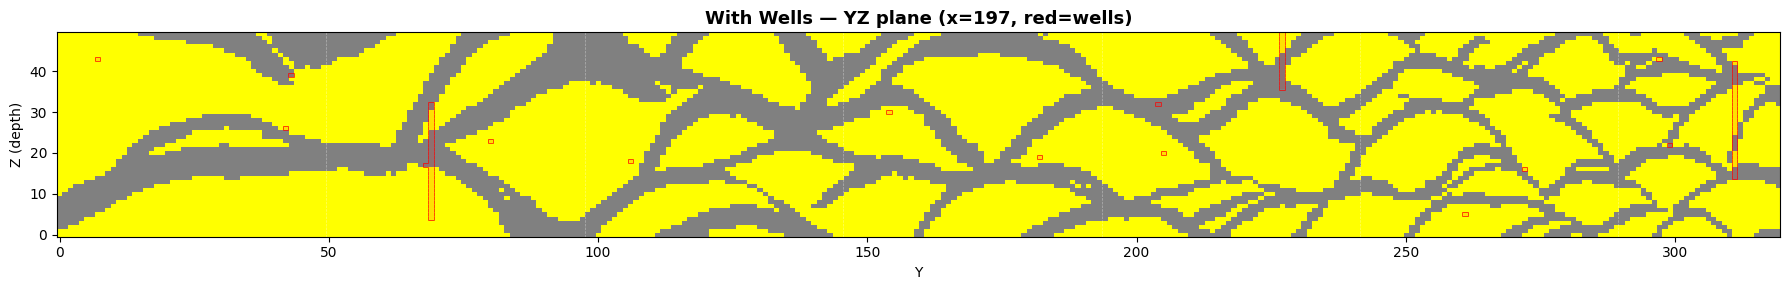

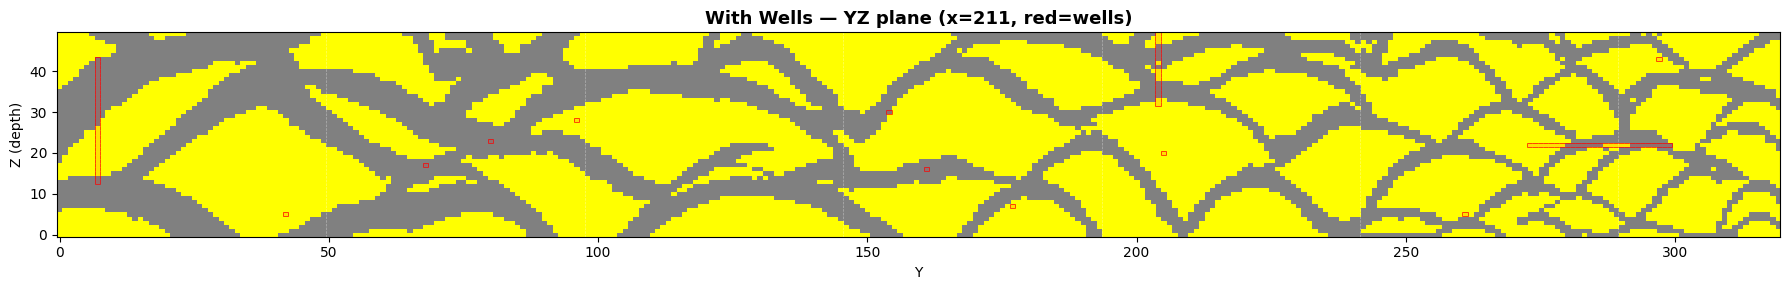

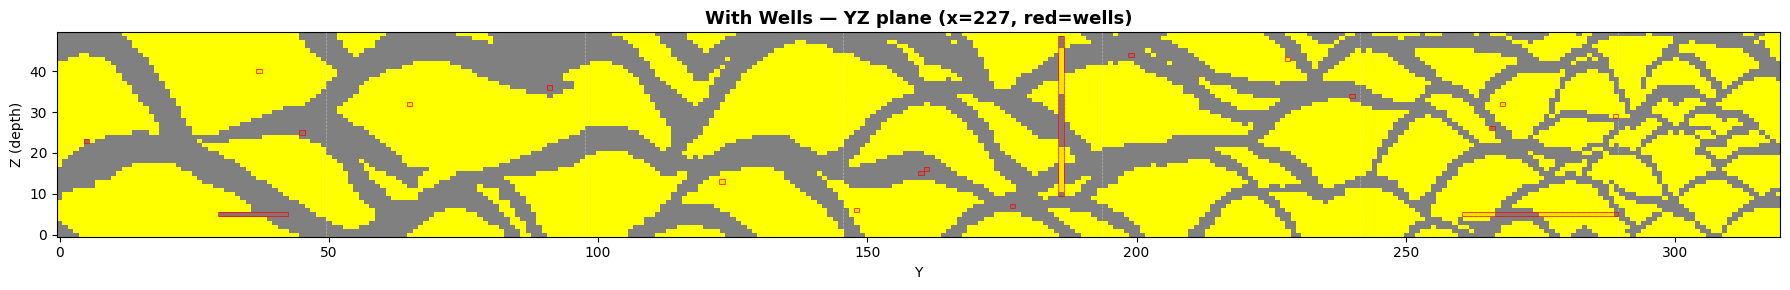

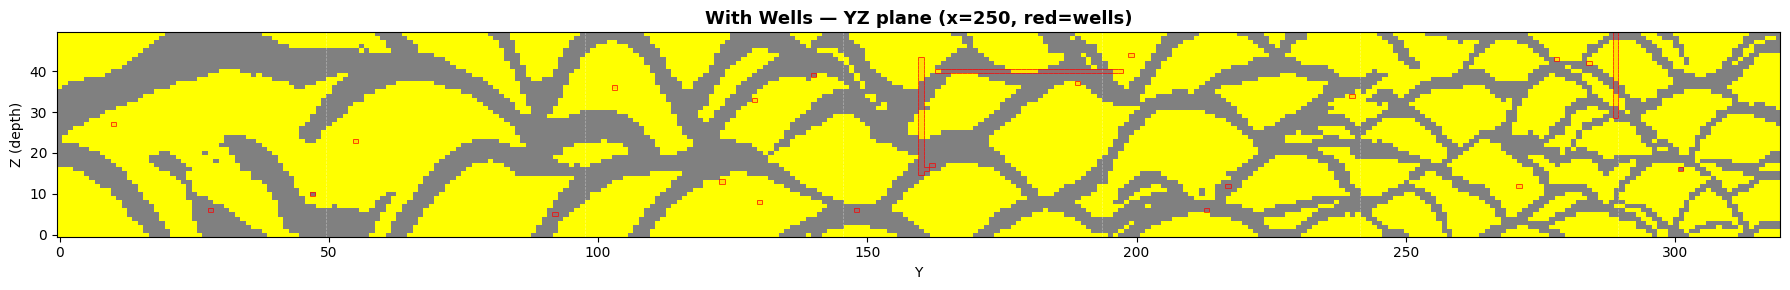

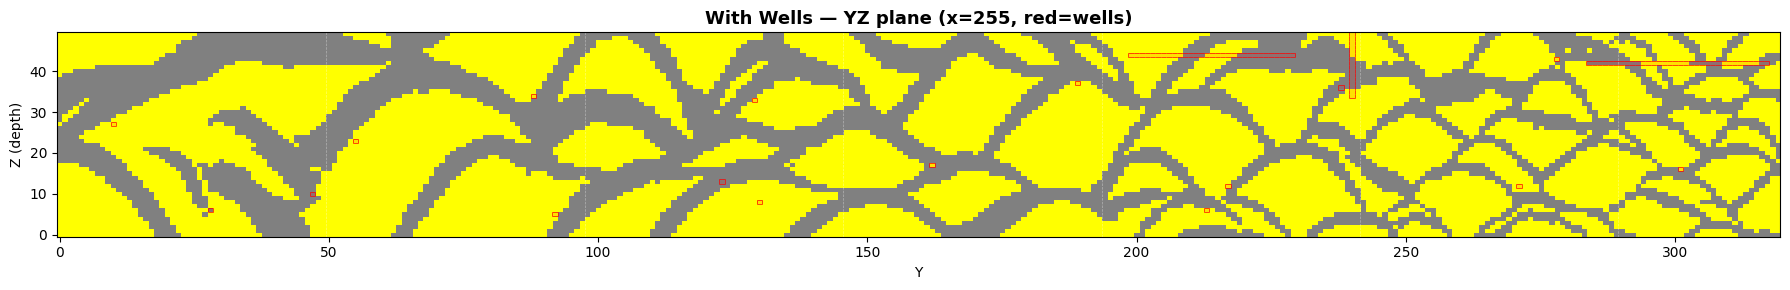

In [37]:
x_slices = np.linspace(10, NX - 10, 8, dtype=int).tolist()

# for x in x_slices:
#     plot_big_slice(res_nw, f'No Wells — YZ plane (x={x})',
#                    slice_axis=0, slice_idx=x, xlabel='Y', ylabel='Z (depth)',
#                    grid_h=NY, figsize=(18, 3))

# For with-wells: pick X positions that pass through wells
x_well_slices = find_well_slices(well_mask, slice_axis=0, n_slices=8)
print(f"X slices through wells: {x_well_slices}")

for x in x_well_slices:
    plot_big_slice(res_ww, f'With Wells — YZ plane (x={x}, red=wells)',
                   slice_axis=0, slice_idx=x, xlabel='Y', ylabel='Z (depth)',
                   well_mask_vol=well_mask, grid_h=NY, figsize=(18, 3))

## Side-by-Side: No Wells vs With Wells

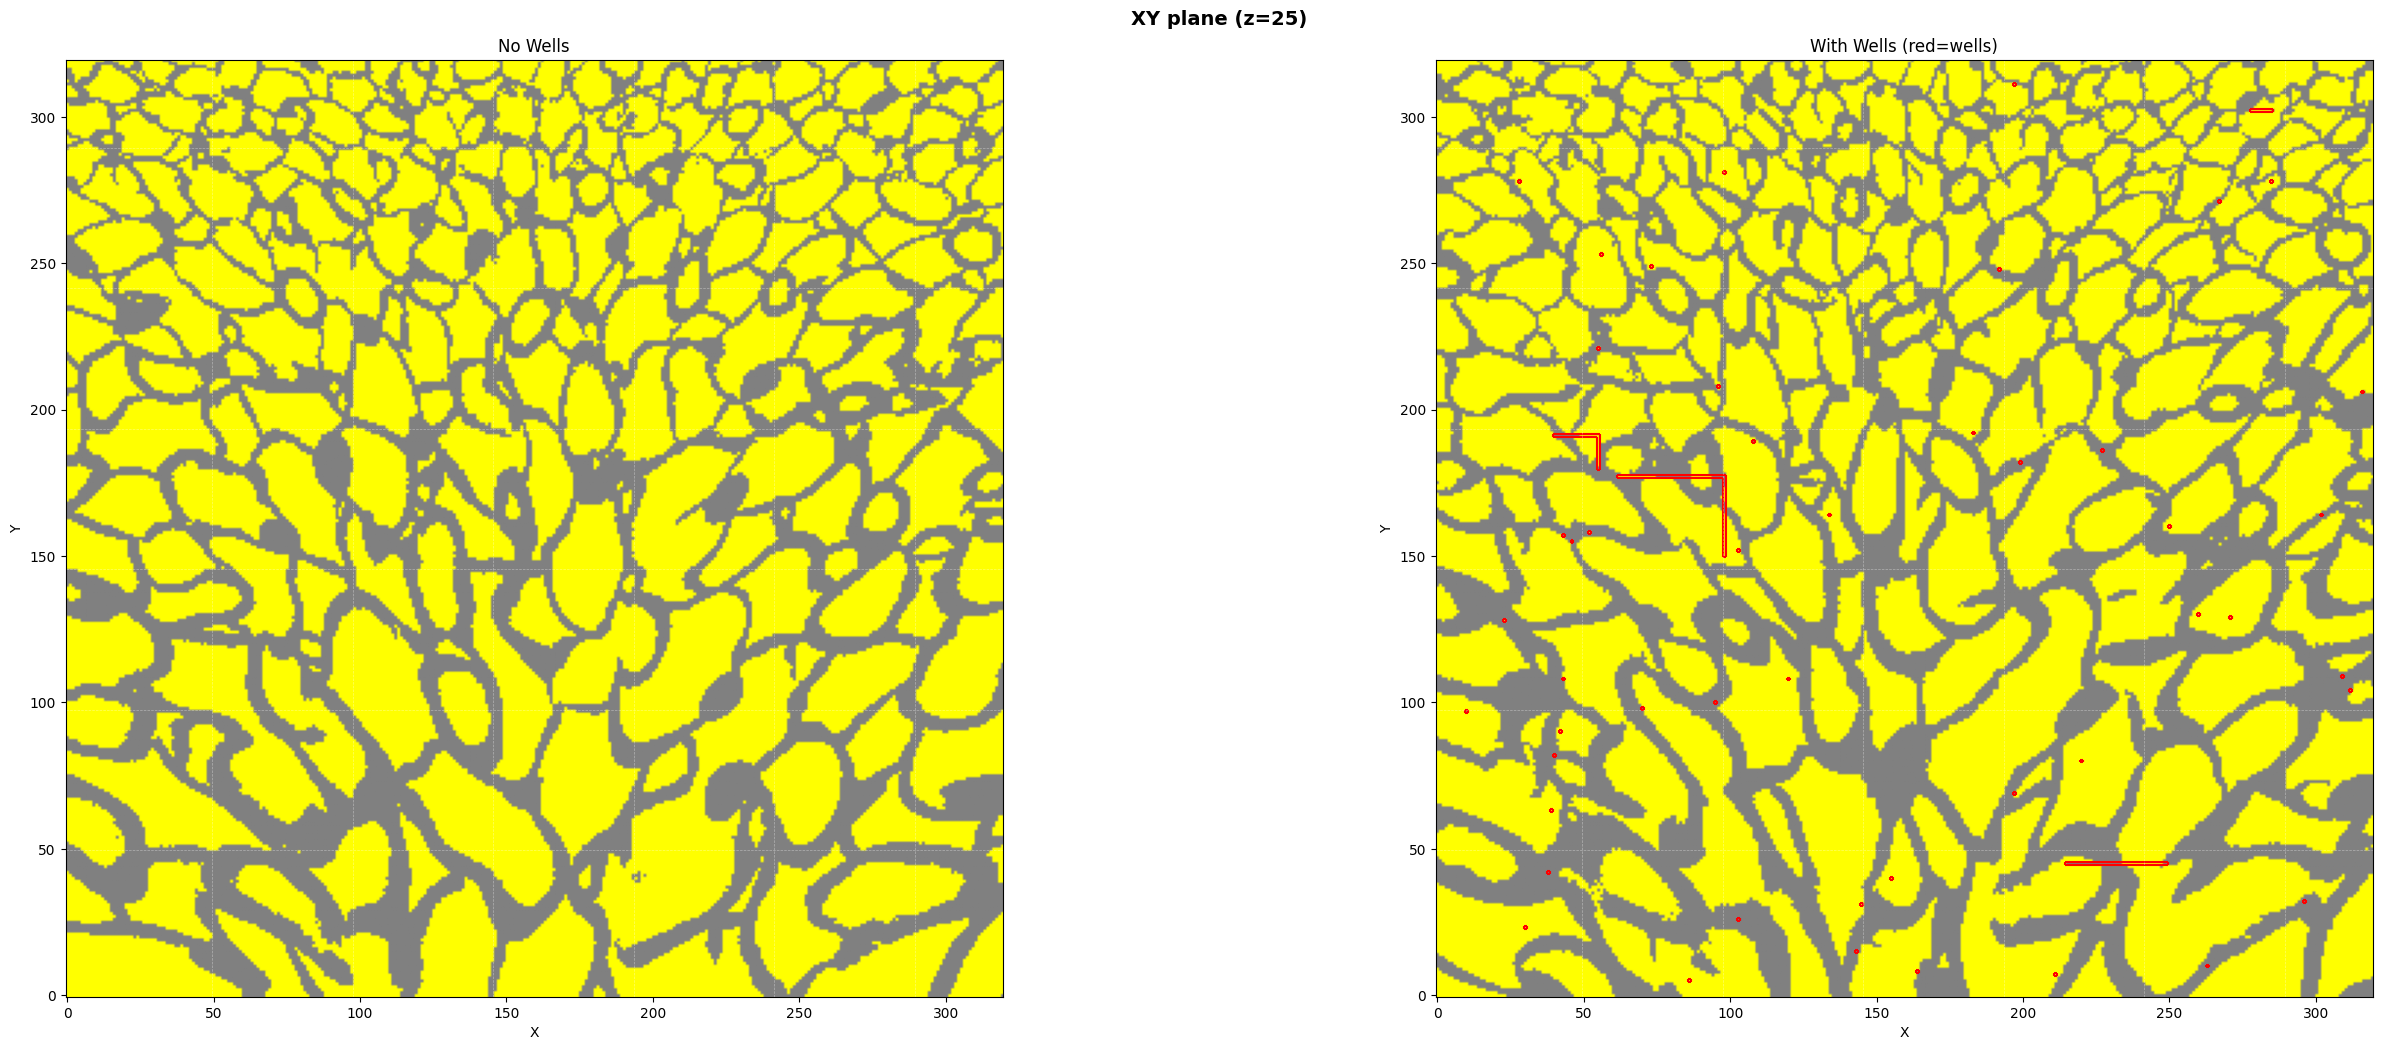

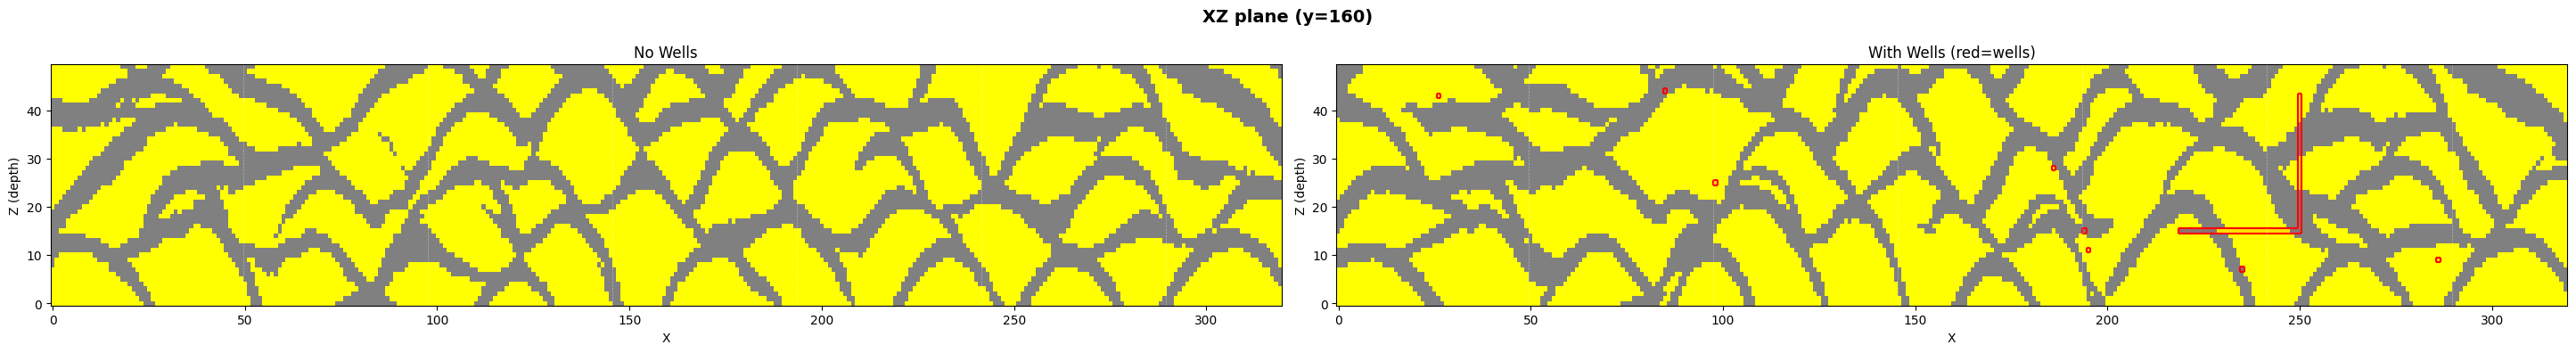

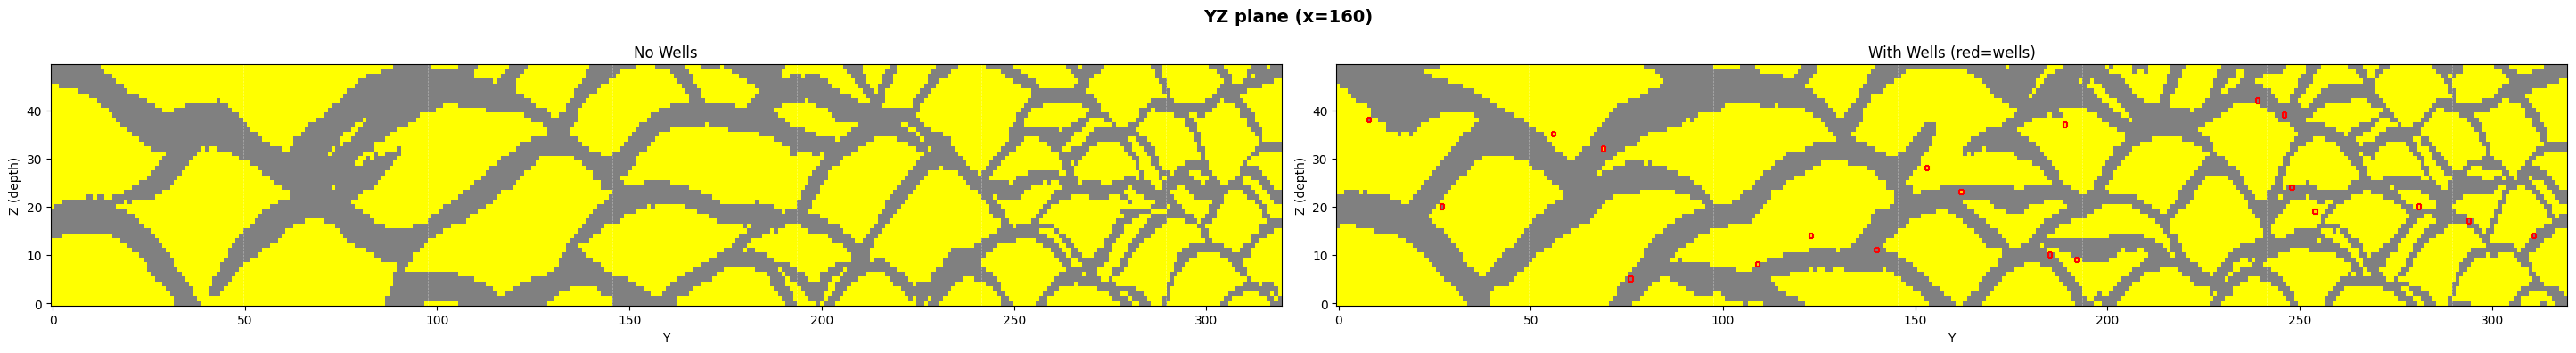

In [38]:
z_mid = NZ // 2
y_mid = NY // 2
x_mid = NX // 2

slices = [
    (2, z_mid, f'XY plane (z={z_mid})', 'X', 'Y'),
    (1, y_mid, f'XZ plane (y={y_mid})', 'X', 'Z (depth)'),
    (0, x_mid, f'YZ plane (x={x_mid})', 'Y', 'Z (depth)'),
]

for axis, idx, plane_title, xl, yl in slices:
    slc_nw = np.take(res_nw, idx, axis=axis).T.astype(float)
    slc_ww = np.take(res_ww, idx, axis=axis).T.astype(float)
    mask_slc = np.take(well_mask, idx, axis=axis).T

    h, w = slc_nw.shape
    fw = max(14, w / 30)
    fh = max(4, h / 30)
    fig, axes = plt.subplots(1, 2, figsize=(fw * 2 + 1, fh))
    fig.suptitle(plane_title, fontsize=14, fontweight='bold')
    asp = 'equal' if h > 100 else 'auto'

    axes[0].imshow(slc_nw, cmap=custom_cmap, vmin=0, vmax=1, origin='lower', aspect=asp)
    axes[0].set_title('No Wells')
    axes[0].set_xlabel(xl); axes[0].set_ylabel(yl)

    axes[1].imshow(slc_ww, cmap=custom_cmap, vmin=0, vmax=1, origin='lower', aspect=asp)
    if mask_slc.any():
        red = np.zeros((*mask_slc.shape, 4))
        red[mask_slc > 0.5] = [1, 0, 0, 0.12]
        axes[1].imshow(red, origin='lower', aspect=asp)
        draw_mask_boundary(axes[1], mask_slc, color='red', linewidth=1.5)
    axes[1].set_title('With Wells (red=wells)')
    axes[1].set_xlabel(xl); axes[1].set_ylabel(yl)

    # Grid lines on both
    for ax in axes:
        if axis == 2:  # XY plane
            draw_block_grid(ax, NX, STRIDE, 'vertical')
            draw_block_grid(ax, NY, STRIDE, 'horizontal')
        elif axis == 1:  # XZ plane
            draw_block_grid(ax, NX, STRIDE, 'vertical')
        else:  # YZ plane
            draw_block_grid(ax, NY, STRIDE, 'vertical')

    plt.tight_layout()
    plt.show()

## Conditioning Map

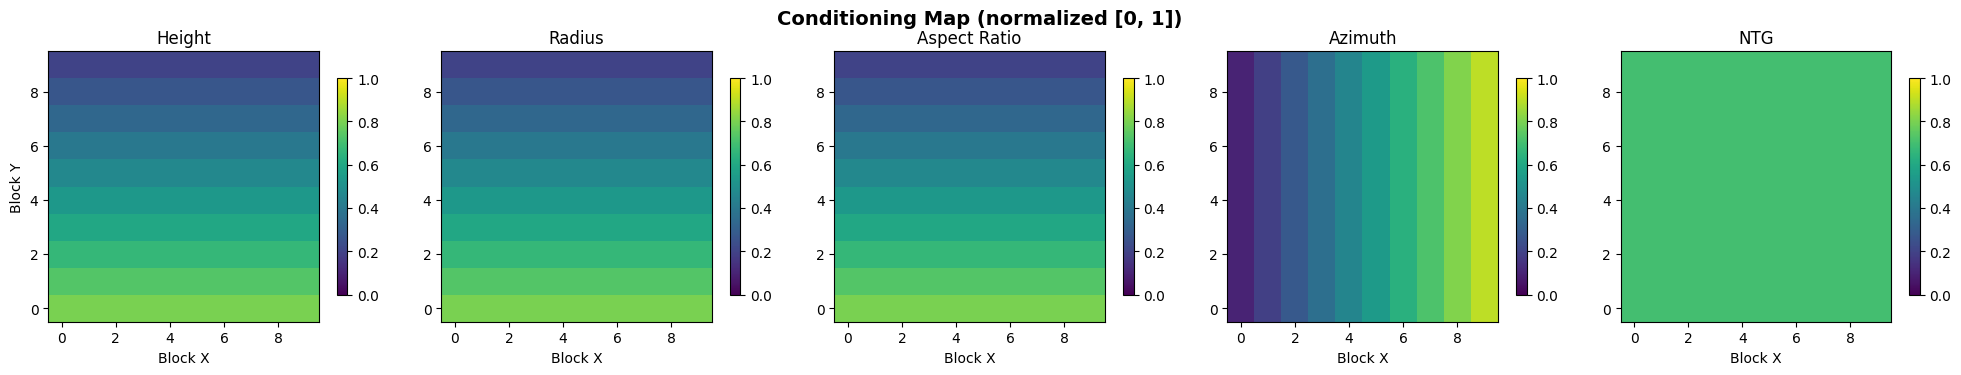

In [39]:
param_names = ['Height', 'Radius', 'Aspect Ratio', 'Azimuth', 'NTG']

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
fig.suptitle('Conditioning Map (normalized [0, 1])', fontsize=14, fontweight='bold')

for col, name in enumerate(param_names):
    im = axes[col].imshow(cond_map[:, :, col], cmap='viridis', vmin=0, vmax=1,
                          origin='lower', aspect='equal')
    axes[col].set_title(name)
    axes[col].set_xlabel('Block X')
    if col == 0:
        axes[col].set_ylabel('Block Y')
    fig.colorbar(im, ax=axes[col], shrink=0.8)

plt.tight_layout()
plt.show()

## Timing

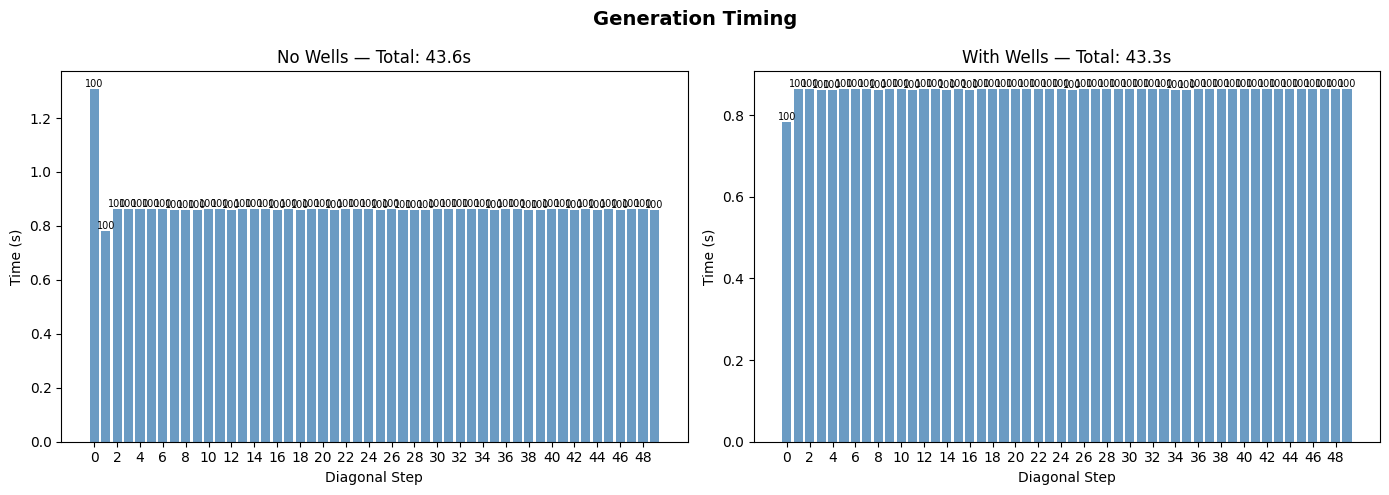

In [40]:
times_nw = timing['times_no_wells']
times_ww = timing['times_with_wells']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Generation Timing', fontsize=14, fontweight='bold')

for ax, times, label, total in [
    (axes[0], times_nw, 'No Wells', float(timing['total_no_wells'])),
    (axes[1], times_ww, 'With Wells', float(timing['total_with_wells'])),
]:
    diags = times[:, 0].astype(int)
    batch_sizes = times[:, 1].astype(int)
    elapsed = times[:, 2]

    bars = ax.bar(diags, elapsed, color='steelblue', alpha=0.8)
    ax.set_xlabel('Diagonal Step')
    ax.set_ylabel('Time (s)')
    ax.set_title(f'{label} — Total: {total:.1f}s')

    for bar, bs in zip(bars, batch_sizes):
        if bar.get_height() > 0.5:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    str(bs), ha='center', va='bottom', fontsize=7)
    ax.set_xticks(diags[::2])

plt.tight_layout()
plt.show()

## Summary Statistics

Scenario                       Shape      NTG   Target NTG
------------------------------------------------------------
No Wells              (320, 320, 50)    0.631        0.500
With Wells            (320, 320, 50)    0.631        0.500


/tmp/ipykernel_1829148/4100878183.py:23: RuntimeWarning: Mean of empty slice
  block_ntg[i, j] = block.mean()


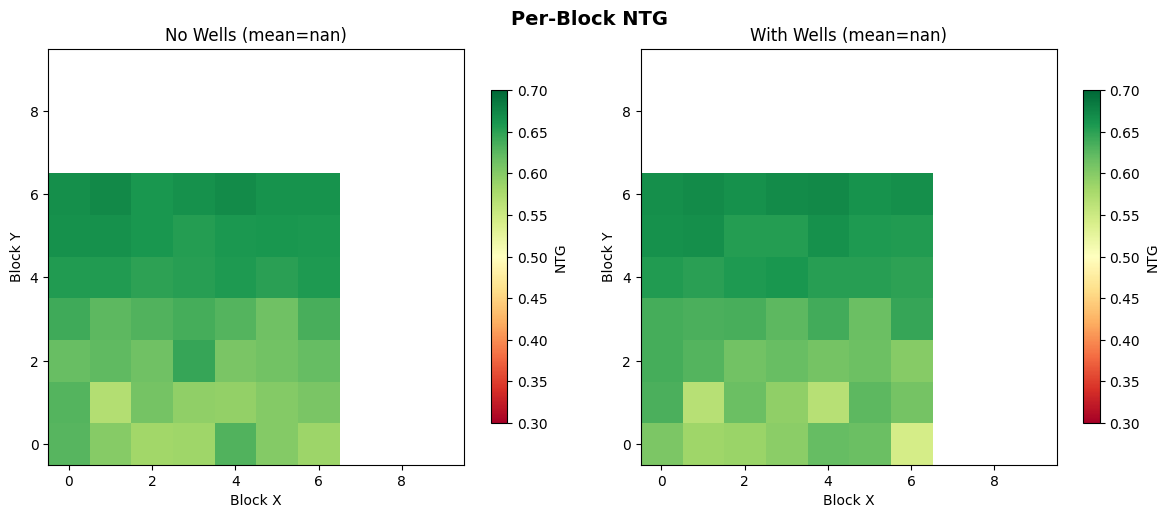

In [41]:
ny, nx = cond_map.shape[:2]
BS = 50

print(f"{'Scenario':<15} {'Shape':>20} {'NTG':>8} {'Target NTG':>12}")
print("-" * 60)
for name, vol in [('No Wells', res_nw), ('With Wells', res_ww)]:
    print(f"{name:<15} {str(vol.shape):>20} {vol.mean():>8.3f} {0.5:>12.3f}")

# Per-block NTG heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Per-Block NTG', fontsize=14, fontweight='bold')

for ax, vol, label in [
    (axes[0], res_nw, 'No Wells'),
    (axes[1], res_ww, 'With Wells'),
]:
    block_ntg = np.zeros((ny, nx))
    for i in range(ny):
        for j in range(nx):
            x_start = j * STRIDE
            y_start = i * STRIDE
            block = vol[x_start:x_start + BS, y_start:y_start + BS, :]
            block_ntg[i, j] = block.mean()

    im = ax.imshow(block_ntg, cmap='RdYlGn', vmin=0.3, vmax=0.7,
                   origin='lower', aspect='equal')
    ax.set_title(f'{label} (mean={block_ntg.mean():.3f})')
    ax.set_xlabel('Block X')
    ax.set_ylabel('Block Y')
    fig.colorbar(im, ax=ax, shrink=0.8, label='NTG')

plt.tight_layout()
plt.show()